## 1. Importando dependencias

In [48]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

---

## 2. Importando o dataset


In [49]:
data_path = r'../data/processed/temperature_data.csv'
dados = pd.read_csv(data_path, delimiter=';')
print(f"Data Path: {data_path}")

Data Path: ../data/processed/temperature_data.csv


---

## 3. Estudo do dataset


In [50]:
print(f"Entendendo o dataset")
print(f"Shape: {dados.shape}")
print(f"Colunas: {dados.shape[1]}")
print(f"Linhas: {dados.shape[0]}")

print(f"\t tipos de dados das colunas:")
print(dados.dtypes)

print(f"\n=== ESTATÍSTICAS DA VARIÁVEL ALVO ===")
if 'temperaturasaidafp' in dados.columns:
    target_stats = dados['temperaturasaidafp'].describe()
    print(target_stats)
else:
    print("Variável alvo 'temperaturasaidafp' não encontrada!") ##tratamento de erro
    print("Colunas disponíveis:", list(dados.columns))

Entendendo o dataset
Shape: (7485, 18)
Colunas: 18
Linhas: 7485
	 tipos de dados das colunas:
corrida                    int64
secao                    float64
acoatual                  object
qualidade                 object
al_min                   float64
c_min                    float64
c_max                    float64
n_min                    float64
s_min                    float64
sequencia                float64
sequenciatotal           float64
panela                   float64
vidapanela               float64
tempociclo               float64
tempovacuototal          float64
temperaturaliquidus      float64
temperaturasaidafp         int64
temperaturaobjetivada    float64
dtype: object

=== ESTATÍSTICAS DA VARIÁVEL ALVO ===
count    7485.000000
mean     1654.005745
std        21.711345
min      1583.000000
25%      1640.000000
50%      1654.000000
75%      1668.000000
max      1753.000000
Name: temperaturasaidafp, dtype: float64


---

## 4. Buscando valores ausentes


In [51]:
print(f"entendendo valores ausentes")
missing_values = dados.isnull().sum()
total_missing = missing_values.sum()

print(f"faltantes: {total_missing}")
if total_missing > 0:
    print(f"\nFaltantes por coluna:")
    print(missing_values[missing_values > 0])
    
  
    print(f"\nFilling missing values:")

    numeric_cols = dados.select_dtypes(include=[np.number]).columns
    filled_numeric = 0
    for col in numeric_cols:
        if dados[col].isnull().sum() > 0:
            median_val = dados[col].median()
            dados[col].fillna(median_val, inplace=True)
            filled_numeric += 1
            print(f"  • {col}: filled with median ({median_val:.2f})")
    
 
    categorical_cols = dados.select_dtypes(include=['object', 'category']).columns
    filled_categorical = 0
    for col in categorical_cols:
        if dados[col].isnull().sum() > 0:
            mode_val = dados[col].mode()[0]
            dados[col].fillna(mode_val, inplace=True)
            filled_categorical += 1
            print(f"  • {col}: filled with mode ({mode_val})")
    
    print(f"\nFilled {filled_numeric} numeric and {filled_categorical} categorical columns")
else:
    print("tudo certo por aqui")

entendendo valores ausentes
faltantes: 0
tudo certo por aqui


---

## 5. Definindo as features categoricas

In [52]:

categorical_features = ['acoatual', 'qualidade']
target_col = 'temperaturasaidafp'

print(f"features categoricas")
print(f"features categoricas: {categorical_features}")

if len(categorical_features) > 0:
    print(f"\nFeatures categóricas:")
    for i, feat in enumerate(categorical_features):
        if feat in dados.columns:
            unique_count = dados[feat].nunique()
            print(f"  {i+1:2}. {feat:25} | Unique values: {unique_count}")
            print(f"      Sample values: {list(dados[feat].unique()[:5])}")
        else:
            print(f"  {i+1:2}. {feat:25} | coluna não encontrada no dataset")
else:
    print("Nenhum recurso categórico definido")


valid_categorical_features = [feat for feat in categorical_features if feat in dados.columns]
if len(valid_categorical_features) != len(categorical_features):
    print(f"\n Warning: {len(categorical_features) - len(valid_categorical_features)} categorical features not found in dataset")
    categorical_features = valid_categorical_features


total_features = dados.shape[1] - 1 
numeric_features = total_features - len(categorical_features)
print(f"\nestudo de features")
print(f"Total: {total_features}")
print(f"Numericas: {numeric_features}")
print(f"Categoricas: {len(categorical_features)}")


print(f"\n=== convertendo cat para string ===")
for feat in categorical_features:
    if feat in dados.columns:

        dados[feat] = dados[feat].astype(str)
        print(f"{feat}: convertida para string")
    
print(f"catgoricas agora sao strings")

features categoricas
features categoricas: ['acoatual', 'qualidade']

Features categóricas:
   1. acoatual                  | Unique values: 3505
      Sample values: ['336236CB', 'D7B079C7', 'E5AB530D', '457B036C', '8F368B5C']
   2. qualidade                 | Unique values: 253
      Sample values: ['1F3F501C', '96956A01', 'A8E02CB3', '7BF6FBDF', '59D14704']

estudo de features
Total: 17
Numericas: 15
Categoricas: 2

=== convertendo cat para string ===
acoatual: convertida para string
qualidade: convertida para string
catgoricas agora sao strings


---

## 6. Preparando as features e a feature target (x e y)

In [53]:

X = dados.drop(columns=[target_col])
y = dados[target_col]

print(f"=== preparando features e a target ===")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target variable: {target_col}")

print(f"\n=== ESTATÍSTICAS DA VARIÁVEL ALVO ===")
print(f"Mean: {y.mean():.2f}")
print(f"Std: {y.std():.2f}")
print(f"Min: {y.min():.2f}")
print(f"Max: {y.max():.2f}")
print(f"Range: {y.max() - y.min():.2f}")

print(f"\n=== colunas de features ===")
feature_list = list(X.columns)
print(f"Total: {len(feature_list)} features")
for i, col in enumerate(feature_list[:10]): 
    print(f"  {i+1:2}. {col}")
if len(feature_list) > 10:
    print(f"  ... and {len(feature_list) - 10} more features")

=== preparando features e a target ===
Features shape: (7485, 17)
Target shape: (7485,)
Target variable: temperaturasaidafp

=== ESTATÍSTICAS DA VARIÁVEL ALVO ===
Mean: 1654.01
Std: 21.71
Min: 1583.00
Max: 1753.00
Range: 170.00

=== colunas de features ===
Total: 17 features
   1. corrida
   2. secao
   3. acoatual
   4. qualidade
   5. al_min
   6. c_min
   7. c_max
   8. n_min
   9. s_min
  10. sequencia
  ... and 7 more features


##  O que este bloco faz

Este bloco prepara X (features) e y (target), imprime shapes, estatísticas básicas do alvo e lista as primeiras features:

- X = dados.drop(columns=[target_col]) → DataFrame com todas as colunas exceto a coluna alvo.
- y = dados[target_col] → Series com a variável alvo.
- Imprime shapes de X e y, nome da variável alvo.
- Mostra estatísticas do alvo: mean, std, min, max, range.
- Lista total de features e mostra os primeiros 10 nomes.

---

##  Passo a passo (resumido)

1. Separar variáveis explicativas (X) e variável resposta (y).  
2. Conferir shapes para garantir que X tem (n_samples, n_features) e y tem (n_samples,).  
3. Verificar estatísticas do alvo para entender escala e dispersão.  
4. Inspecionar nomes das features — útil para validar colunas categóricas e pipeline.

---

## O que fica em X e o que fica em y (explicação prática)

- X (features):
  - Contém todas as colunas usadas como entrada do modelo (preditores).
  - É um DataFrame 2D: cada linha = uma amostra, cada coluna = uma feature.
  - Pode conter colunas numéricas e categóricas.  
  - Ordem e nomes das colunas em X no treino devem ser os mesmos ao fazer predições.

- y (target):
  - Contém o valor que o modelo deve prever.
  - É uma Series 1D com mesmo número de linhas que X.
  - Para regressão (como temperatura) deve ser numérico; para classificação são rótulos (podem ser strings ou inteiros).

---

## Como CatBoost usa X e y

- CatBoost aceita diretamente:
  - model.fit(X, y) com X = DataFrame/ndarray e y = Series/array.
  - Ou usar Pool(data=X, label=y, cat_features=...) para passar metadados (recomendado quando há features categóricas, pesos, grupos).
- Tratamento de categóricas:
  - Informe as colunas categóricas via cat_features (nomes ou índices) ou converta para str/category antes de criar Pool.
  - CatBoost aplica codificação interna ótima para categoricals (target encoding, permutations), por isso é preferível não fazer One-Hot manual.
- Requisitos:
  - X e y devem ter mesma ordem e número de amostras.
  - Ao salvar/usar o modelo em produção, garanta que as colunas de entrada estejam na mesma ordem e formato (tipos) que no treino.
- Boas práticas:
  - Converter categóricas para str ou category antes do Pool.
  - Remover colunas com vazamento de informação (IDs temporais, targets futuros).
  - Verificar distribuição do target (outliers / escala) antes de treinar.

---

## Verificações rápidas sugeridas

- Confirme len(X) == len(y).  
- Verifique dtypes de X (X.dtypes) e converta categóricas: X[cat] = X[cat].astype(str).  
- Checar se target_col não está em X (já removido pelo drop).  
- Use Pool(X, y, cat_features=...) ao treinar para controle total.

---

## 7. Dividindo os dados para test e train

In [54]:
test_size = 0.2
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=test_size, 
    random_state=random_state,
    stratify=None  
)

print(f"=== DIVISÃO DOS DADOS ===")
print(f"Tamanho do conjunto de teste: {test_size:.1%}")
print(f"Semente aleatória: {random_state}")

print(f"\n=== RESULTADO DA DIVISÃO ===")
print(f"Conjunto de treinamento: {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X):.1%})")
print(f"Conjunto de teste: {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X):.1%})")
print(f"Número de features: {X_train.shape[1]}")

print(f"\n=== DISTRIBUIÇÃO DO ALVO POR CONJUNTO ===")
print(f"Treinamento - Média: {y_train.mean():.2f}, Desvio padrão: {y_train.std():.2f}")
print(f"Teste        - Média: {y_test.mean():.2f}, Desvio padrão: {y_test.std():.2f}")

=== DIVISÃO DOS DADOS ===
Tamanho do conjunto de teste: 20.0%
Semente aleatória: 42

=== RESULTADO DA DIVISÃO ===
Conjunto de treinamento: 5,988 amostras (80.0%)
Conjunto de teste: 1,497 amostras (20.0%)
Número de features: 17

=== DISTRIBUIÇÃO DO ALVO POR CONJUNTO ===
Treinamento - Média: 1653.97, Desvio padrão: 21.63
Teste        - Média: 1654.14, Desvio padrão: 22.05


##  O que este bloco faz

Este bloco divide o dataset em conjuntos de treino e teste e imprime informações resumidas sobre a divisão e a distribuição da variável alvo.

- Executa `train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=None)` para criar:
  - X_train, y_train → dados de treino
  - X_test, y_test → dados de teste
- Imprime parâmetros usados (tamanho do teste e semente) e resultados (nº de amostras em cada conjunto, percentual e nº de features).
- Imprime estatísticas simples da variável alvo em treino e teste (média e desvio padrão) para checar se a divisão alterou fortemente a distribuição do target.

---

##  Parâmetros chave

- test_size = 0.2 → 20% dos registros ficam no conjunto de teste.
- random_state = 42 → semente para tornar a divisão reprodutível.
- stratify = None → divisão aleatória sem estratificação (use estratify=y para problemas de classificação com classes desbalanceadas).

---

##  O que conferir após a divisão

- Tamanhos: X_train.shape / X_test.shape correspondem às proporções esperadas.
- Número de features: X_train.shape[1] deve ser igual ao de X.
- Distribuição do target: compare média e desvio padrão entre y_train e y_test — grandes diferenças podem indicar necessidade de estratificação ou revisão da amostra.
- Verifique vazamento de dados (leakage) entre treino e teste (ex.: colunas temporais, IDs).

---

##  Boas práticas rápidas

- Para classificação com classes desbalanceadas, use stratify=y.
- Para séries temporais, não use train_test_split aleatório; faça divisão temporal (por data).
- Mantenha `random_state` fixo para resultados reproduzíveis durante desenvolvimento e comparações de modelos.
- Confirme que índices/ordens não expõem informações do futuro ao treino (shuffle/ordem).

---

## Exemplo resumido de uso

- `train_test_split(X, y, test_size=0.2, random_state=42)`
- Verificar: `len(X_train), len(X_test), X_train.shape[1], y_train.mean(), y_test.mean()`



## 8. Criando as pools do catboost

In [55]:
print(f"=== CRIANDO POOLS DO CATBOOST ===")

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=categorical_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=categorical_features
)

print(f" Pool de treinamento criado:")
print(f"  • Amostras: {train_pool.num_row():,}")
print(f"  • Número de features: {train_pool.num_col()}")
print(f"  • Features categóricas: {len(categorical_features)}")

print(f"\n Pool de teste criado:")
print(f"  • Amostras: {test_pool.num_row():,}")
print(f"  • Número de features: {test_pool.num_col()}")
print(f"  • Features categóricas: {len(categorical_features)}")

if len(categorical_features) > 0:
    print(f"\n=== FEATURES CATEGÓRICAS NOS POOLS ===")
    for i, feat in enumerate(categorical_features[:5]):  # Mostrar os 5 primeiros
        print(f"  {i+1}. {feat}")
    if len(categorical_features) > 5:
        print(f"  ... e mais {len(categorical_features) - 5}")

=== CRIANDO POOLS DO CATBOOST ===
 Pool de treinamento criado:
  • Amostras: 5,988
  • Número de features: 17
  • Features categóricas: 2

 Pool de teste criado:
  • Amostras: 1,497
  • Número de features: 17
  • Features categóricas: 2

=== FEATURES CATEGÓRICAS NOS POOLS ===
  1. acoatual
  2. qualidade


## O que este bloco faz

Este trecho cria os "pools" (estruturas de dados do CatBoost) para treino e teste e imprime informações resumidas para checagem rápida:

- Cria `train_pool` e `test_pool` com:
  - data = X_train / X_test
  - label = y_train / y_test
  - cat_features = lista de features categóricas
- Imprime informações básicas dos pools:
  - número de amostras (`num_row()`)
  - número de features (`num_col()`)
  - quantidade de features categóricas
- Se houver features categóricas, lista as 5 primeiras para verificação rápida.

---

##  Passo a passo (resumido)
1. Construir Pool de treino com dados e rótulos.
2. Construir Pool de teste com dados e rótulos.
3. Mostrar quantas amostras e colunas cada pool tem.
4. Mostrar quantas features categóricas foram informadas e listar as primeiras.

---

##  O que é um Pool (CatBoost) e por que usar

- Pool é a estrutura de dados nativa do CatBoost que encapsula:
  - as features (X),
  - os rótulos (y),
  - informação de quais colunas são categóricas,
  - (opcional) pesos, grupos, metadados, etc.
- Vantagens de usar Pool:
  - Garante que o CatBoost trate corretamente features categóricas (evita conversão errada para numérico).
  - Otimizações internas: carregamento e processamento mais eficientes (memória/velocidade).
  - Permite passar metadados úteis (pesos, grupos para ranking, etc.).
  - Reduz chance de discrepância entre treino/avaliação (mesmo pipeline de pré-processamento para ambos).

---

## Boas práticas / observações
- Certifique-se de que `categorical_features` contenha nomes (ou índices) válidos presentes em `X_train`/`X_test`.
- Converta colunas categóricas para `str` ou `category` antes de criar o Pool (o notebook já faz isso em células anteriores).
- O CatBoost aceita DataFrame direto em `fit`, mas usar `Pool` é recomendado quando se quer controle total sobre metadados (cat_features, pesos, grupos).
- Verifique que a ordem/colunas do Pool são as mesmas quando aplicar o modelo em dados novos.

---

## Exemplo de uso rápido
- `train_pool.num_row()` → número de linhas no pool de treino  
- `train_pool.num_col()` → número total de features no pool



---

## 9. Configurando hiperparametros do modelo Catboost

In [56]:
# Configurar modelo CatBoost com hiperparâmetros
print(f"=== CONFIGURAÇÃO DO MODELO CATBOOST ===")

model = CatBoostRegressor(
    iterations=1000,           # Número de iterações de boosting
    learning_rate=0.1,         # Taxa de aprendizado
    depth=6,                   # Profundidade das árvores
    l2_leaf_reg=3,             # Regularização L2 nas folhas
    random_strength=1,         # Intensidade do ruído ao avaliar splits
    bagging_temperature=1,     # Temperatura para o bootstrap bayesiano (bagging)
    od_type='Iter',            # Tipo de detecção de overfitting (early stopping)
    od_wait=50,                # Paciência do early stopping (número de iterações)
    random_seed=42,            # Semente para reprodutibilidade
    verbose=100,               # Exibe progresso a cada N iterações
    eval_metric='RMSE',        # Métrica de avaliação
    use_best_model=True        # Usar o melhor modelo observado na validação
)

# Exibir configuração do modelo
params = model.get_params()
print("Hiperparâmetros do modelo:")
print(f"  • Iterações: {params['iterations']}")
print(f"  • Taxa de aprendizado: {params['learning_rate']}")
print(f"  • Profundidade das árvores: {params['depth']}")
print(f"  • Regularização L2 nas folhas: {params['l2_leaf_reg']}")
print(f"  • Early stopping (paciência): {params['od_wait']} iterações")
print(f"  • Métrica de avaliação: {params['eval_metric']}")
print(f"  • Semente aleatória: {params['random_seed']}")
print(f"  • Features categóricas: {len(categorical_features)}")

=== CONFIGURAÇÃO DO MODELO CATBOOST ===
Hiperparâmetros do modelo:
  • Iterações: 1000
  • Taxa de aprendizado: 0.1
  • Profundidade das árvores: 6
  • Regularização L2 nas folhas: 3
  • Early stopping (paciência): 50 iterações
  • Métrica de avaliação: RMSE
  • Semente aleatória: 42
  • Features categóricas: 2




## Configuração do CatBoost e explicação completa dos hiperparâmetros

Esta célula configura um CatBoostRegressor. Abaixo está a explicação teórica e matemática necessária para entender cada parâmetro, seus efeitos e recomendações práticas.

### Visão geral do CatBoost
- CatBoost é um algoritmo de gradient boosting sobre árvores de decisão. A ideia central do boosting é construir um modelo por etapas, onde a previsão acumulada após m iterações é:
  F_m(x) = F_{m-1}(x) + η · T_m(x)
  em que η é o learning_rate e T_m é a árvore adicionada na iteração m.
- Para uma função de perda L(y, ŷ), o boosting ajusta T_m para reduzir gradientes da perda. Para perda quadrática (MSE), gradiente por amostra i é (ŷ_i − y_i) e a hessiana é constante 1, o que simplifica atualizações de folha.
- Particularidades do CatBoost:
  - Ordered boosting: reduz target leakage ao computar estatísticas para features categóricas usando permutações/ordens dos dados.
  - Codificação interna de categóricas baseada em estatísticas (com técnicas para evitar leakage).

---

### Hiperparâmetros listados 

1. iterations (1000)
   - Definição: número máximo de iterações/árvores (boosting rounds).
   - Matemática/efeito: cada iteração adiciona η·T_m. Mais iterações reduzem viés (modelo mais expressivo) mas aumentam risco de overfitting e custo computacional.
   - Uso: ajustar em conjunto com learning_rate; usar early stopping para evitar treinar até o máximo.

2. learning_rate (η = 0.1)
   - Definição: fator de shrinkage que multiplica a contribuição de cada árvore.
   - Matemática/efeito: passo do gradiente funcional. Pequenos η (ex.: 0.01) exigem mais árvores; grandes η aceleram aprendizado mas podem causar overfitting.
   - Trade-off: velocidade de convergência vs. generalização.

3. depth (6)
   - Definição: profundidade máxima das árvores (número máximo de níveis).
   - Matemática/efeito: uma árvore de profundidade d tem até 2^d folhas; profundidade controla capacidade de modelar interações complexas entre features.
   - Implicação: maior depth → menor viés, maior variância e risco de overfitting; custo computacional aumenta.

4. l2_leaf_reg (λ = 3)
   - Definição: penalização L2 aplicada ao valor das folhas.
   - Matemática: ao estimar valor v* da folha, CatBoost resolve algo similar a v* = −Σ(grad) / (Σ(hess) + λ). A presença de λ suaviza o valor estimado da folha.
   - Efeito: λ maior → valores de folha menores (mais regularização) → reduz variância, aumenta viés.

5. random_strength (1)
   - Definição: magnitude de ruído adicionado ao score de splits durante construção da árvore.
   - Matemática/efeito: pequenas perturbações aleatórias no critério de ganho de split ajudam a evitar empates e splits determinísticos baseados em ruído, aumentando diversidade entre árvores.
   - Uso: útil quando vários splits têm ganhos similares; muito alto pode degradar qualidade.

6. bagging_temperature (1)
   - Definição: controla intensidade do “Bayesian bootstrap” usado pelo CatBoost (amostragem ponderada de instâncias).
   - Intuição/matemática: gera pesos estocásticos para amostras; temperatura T regula dispersão desses pesos. Valores baixos → amostragem mais agressiva; valores altos → pesos mais uniformes.
   - Efeito: regularização via amostragem; pode reduzir overfitting.

7. od_type ('Iter') e od_wait (50)
   - Definição: od_type define o tipo de early stopping; 'Iter' monitora o progresso por iterações. od_wait é a paciência (número de iterações sem melhora na métrica de validação antes de parar).
   - Efeito: interrompe o treino quando não há melhora, e com use_best_model=True restaura o melhor checkpoint. Economiza tempo e reduz overfitting.

8. random_seed (42)
   - Definição: semente para procedimentos aleatórios (bagging, ruído de splits, permutações em ordered boosting).
   - Efeito: garante reprodutibilidade; sem semente resultados podem variar entre execuções.

9. verbose (100)
   - Definição: frequência de logs de treinamento (a cada N iterações).
   - Efeito: apenas informação para usuário, sem impacto no aprendizado.

10. eval_metric ('RMSE')
    - Definição: métrica usada para validar e monitorar performance no conjunto de validação. RMSE = sqrt(mean((y − ŷ)^2)).
    - Implicação: penaliza erros quadráticos, sensível a outliers. Alternativas: MAE, Huber, etc., dependendo do objetivo.

11. use_best_model (True)
    - Definição: ao usar early stopping, garante restaurar o modelo da melhor iteração observada no conjunto de validação.
    - Efeito: evita retornar um modelo de iteração posterior que empiorou.

---

### Conceitos matemáticos essenciais relacionados
- Gradient boosting (descida de gradiente funcional): adiciona modelos para reduzir o gradiente da função de perda.
- Gradiente (g_i) e Hessiana (h_i): premières e segundas derivadas da loss; CatBoost pode usar ambas para estimativas tipo Newton para valores de folha.
- Shrinkage (learning_rate): escala a atualização a cada passo → v_{m} = v_{m-1} + η·Δ.
- Regularização L2 em folhas: adiciona λ·v^2 ao critério, resultando em denominador Σ(hess)+λ na solução da folha.
- Bias vs Variância: parâmetros depth, iterations, learning_rate e l2_leaf_reg afetam esse trade-off.
- Ordered boosting e codificação de categóricas do CatBoost: técnicas para evitar target leakage quando se calcula estatísticas de categorias.

---

### Implicações práticas e recomendações de tuning
- Padrão razoável inicial: depth 4–8, learning_rate 0.01–0.1, iterations 500–5000 dependendo do η.
- Use early stopping (od_wait) e use_best_model para evitar overfitting e salvar tempo.
- Se overfitting: aumentar l2_leaf_reg, diminuir depth, reduzir learning_rate, aumentar bagging_temperature.
- Se underfitting: aumentar depth, aumentar iterations, diminuir l2_leaf_reg ou aumentar learning_rate (com cautela).
- Ajustes finos:
  - random_strength e bagging_temperature são formas de regularização estocástica — úteis em dados ruidosos.
  - Para muitos dados categóricos, confie no tratamento interno do CatBoost em vez de one-hot manual.
- Métrica: escolha eval_metric alinhada ao objetivo de negócio (ex.: RMSE para minimizar erro quadrático; MAE para menor sensibilidade a outliers).

---

### O que as impressões nesta célula mostram
- `params = model.get_params()` recupera os hiperparâmetros.
- As linhas seguintes mostram valores principais (iterations, learning_rate, depth, l2, od_wait, eval_metric, random_seed, número de features categóricas) para validação manual antes do treino.

---

### Resumo rápido (boas práticas)
- Balancear learning_rate e iterations: menor η → mais iterações.
- Regularize com l2_leaf_reg, bagging_temperature ou reduzindo depth.
- Use ordered boosting/codificação interna para categóricas.
- Monitore com eval_set + early stopping e use_best_model=True.
- Fixar random_seed para reprodutibilidade.


---

## 10. Treinando o modelo


In [57]:
print(f"=== TREINAMENTO DO MODELO ===")
print("Iniciando treinamento do CatBoost com monitoramento de validação...")
print("Progresso será exibido a cada 100 iterações")
print("-" * 60)

# Treinar o modelo
model.fit(
    train_pool,
    eval_set=test_pool,
    verbose=100,
    plot=False
)

print("-" * 60)
print("Treinamento concluído com sucesso!")

# Obter informações do treinamento
print(f"\n=== RESULTADOS DO TREINAMENTO ===")
print(f"Melhor iteração: {model.get_best_iteration()}")
print(f"Total de árvores: {model.tree_count_}")
print(f"Melhor pontuação de validação: {model.get_best_score()['validation']['RMSE']:.4f}")

# Verificar se o early stopping foi acionado
if model.get_best_iteration() < params['iterations'] - 1:
    print(f" Early stopping acionado na iteração {model.get_best_iteration()}")
else:
    print(f"Treinamento completou todas as {params['iterations']} iterações")

=== TREINAMENTO DO MODELO ===
Iniciando treinamento do CatBoost com monitoramento de validação...
Progresso será exibido a cada 100 iterações
------------------------------------------------------------
0:	learn: 20.1204361	test: 20.5001295	best: 20.5001295 (0)	total: 72.8ms	remaining: 1m 12s
100:	learn: 6.6059399	test: 6.8668377	best: 6.8668377 (100)	total: 8.59s	remaining: 1m 16s
200:	learn: 5.9465295	test: 6.6618314	best: 6.6612962 (198)	total: 16.8s	remaining: 1m 6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 6.624576418
bestIteration = 243

Shrink model to first 244 iterations.
------------------------------------------------------------
Treinamento concluído com sucesso!

=== RESULTADOS DO TREINAMENTO ===
Melhor iteração: 243
Total de árvores: 244
Melhor pontuação de validação: 6.6246
 Early stopping acionado na iteração 243


# Treinamento do modelo — o que este bloco faz e conceitos associados

## Resumo rápido
Este bloco realiza o treinamento do CatBoostRegressor usando os Pools já preparados (train_pool e test_pool), monitora a validação durante o treino, aplica early stopping e imprime informações finais (melhor iteração, número de árvores e melhor RMSE de validação).

## Passos principais
1. Impressões iniciais — mensagens ao usuário sobre início e frequência de logs.
2. model.fit(train_pool, eval_set=test_pool, verbose=100, plot=False)
   - Executa o boosting usando os dados de treino.
   - `eval_set` fornece um conjunto de validação que o CatBoost usa para monitorar performance.
   - `verbose=100` controla a frequência de logs durante o treino.
   - `plot=False` desativa plot interativo de progresso.
3. Após o fit, obtém:
   - `model.get_best_iteration()` — iteração com melhor desempenho na validação (quando se usa early stopping).
   - `model.tree_count_` — número total de árvores construídas.
   - `model.get_best_score()['validation']['RMSE']` — melhor RMSE observado no conjunto de validação.
4. Verificação de early stopping:
   - Compara a melhor iteração com o número máximo (`params['iterations']`) para saber se o treino parou antes do limite.

## Conceitos associados
- Pool (CatBoost): estrutura que contém dados, rótulos e informação de colunas categóricas. Permite ao CatBoost aplicar tratamento específico para categóricas sem one‑hot manual.
- eval_set / validação: conjunto usado para monitorar a métrica (aqui RMSE) em cada iteração; não participa diretamente do ajuste dos parâmetros internos do modelo, serve para avaliação.
- RMSE (Root Mean Square Error): métrica de regressão sensível a erros grandes (outliers). É a raiz quadrada da média dos quadrados dos erros.
- verbose / logs: permitem acompanhar progresso do treino; útil para detectar problemas (por ex. converge rápido ou overfitting).
- Early stopping (`od_type`, `od_wait`, `use_best_model`):
  - `od_wait` define paciência — quantas iterações sem melhora antes de parar.
  - `od_type='Iter'` monitora por iterações.
  - `use_best_model=True` faz o CatBoost restaurar o checkpoint com a melhor performance na validação.
- Best iteration vs iterations: se `get_best_iteration()` for muito menor que `iterations`, significa que o early stopping interrompeu o treino porque a métrica de validação não melhorou.
- tree_count_: cada iteração adiciona uma (ou mais) árvore(s); o atributo retorna quantas árvores foram efetivamente treinadas.

## Boas práticas / recomendações rápidas
- Confirmar que `eval_set` representa bem dados fora da amostra (mesma distribuição).
- Ajustar `learning_rate` e `iterations` em conjunto (menor learning_rate geralmente pede mais iterações).
- Se houver overfitting: aumentar regularização (l2_leaf_reg), aumentar bagging_temperature, reduzir depth ou usar mais dados de validação.
- Usar `random_seed` para reprodutibilidade.
- Salvar modelo e métricas após treino (já presente em células posteriores do notebook).
- Considerar validação cruzada (cv) para estimativas mais robustas da performance.

## Interpretação das impressões finais
- `Melhor iteração` e `Melhor pontuação de validação` ajudam a escolher o checkpoint final salvo por `use_best_model`.

---

## 11. # Predições, Avaliação e Análises Pós‑Treino

In [58]:
print(f"=== GERANDO PREDIÇÕES ===")

# Gerar predições
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Predições de treino geradas: {len(y_pred_train):,} amostras")
print(f"Predições de teste geradas: {len(y_pred_test):,} amostras")

# Exibir estatísticas das predições
print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
print(f"Predições de treino:")
print(f"  • Média: {y_pred_train.mean():.2f}")
print(f"  • Desvio padrão: {y_pred_train.std():.2f}")
print(f"  • Mínimo: {y_pred_train.min():.2f}")
print(f"  • Máximo: {y_pred_train.max():.2f}")

print(f"\nPredições de teste:")
print(f"  • Média: {y_pred_test.mean():.2f}")
print(f"  • Desvio padrão: {y_pred_test.std():.2f}")
print(f"  • Mínimo: {y_pred_test.min():.2f}")
print(f"  • Máximo: {y_pred_test.max():.2f}")

# Comparação rápida predição vs real
print(f"\n=== EXEMPLOS DE PREDIÇÕES (CONJUNTO DE TESTE) ===")
comparison_df = pd.DataFrame({
    'Real': y_test.values[:5],
    'Previsto': y_pred_test[:5],
    'Erro': y_test.values[:5] - y_pred_test[:5]
})
print(comparison_df.round(2))

=== GERANDO PREDIÇÕES ===
Predições de treino geradas: 5,988 amostras
Predições de teste geradas: 1,497 amostras

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Predições de treino:
  • Média: 1654.00
  • Desvio padrão: 20.61
  • Mínimo: 1598.28
  • Máximo: 1729.07

Predições de teste:
  • Média: 1653.91
  • Desvio padrão: 20.74
  • Mínimo: 1606.15
  • Máximo: 1728.41

=== EXEMPLOS DE PREDIÇÕES (CONJUNTO DE TESTE) ===
   Real  Previsto  Erro
0  1635   1636.81 -1.81
1  1654   1653.45  0.55
2  1624   1625.15 -1.15
3  1683   1675.15  7.85
4  1631   1638.60 -7.60


# Predições, Avaliação e Análises Pós‑Treino — Explicação detalhada

## Resumo
Nesta sequência de células são geradas predições com o modelo treinado, calculadas métricas de desempenho (treino e teste), realizadas análises de overfitting e importância de features, salvo o modelo e artefatos, carregado o modelo salvo, aplicadas predições em dados reais e feita uma série de comparações e visualizações. Abaixo está a descrição passo a passo do que cada parte faz e os conceitos associados.

---

## 1) Geração de predições (train / test)
- Código:
  - y_pred_train = model.predict(X_train)
  - y_pred_test = model.predict(X_test)
- O que faz:
  - Aplica o modelo treinado para produzir saídas contínuas (regressão) para conjuntos de treino e teste.
  - Conta e imprime quantas predições foram geradas.
- Por que é útil:
  - Permite avaliar desempenho no mesmo conjunto usado para treinar (checar underfitting) e no conjunto fora da amostra (generalização).

## 2) Estatísticas das predições
- Estatísticas calculadas: média, desvio padrão, mínimo e máximo para predições de treino e teste.
- Interpretação:
  - Média e desvio indicam tendência central e dispersão das predições.
  - Mínimo/máximo ajudam a identificar previsões fora do intervalo esperado (potenciais outliers ou erro de escala).
- Recomendações:
  - Conferir se as predições têm escala compatível com a variável alvo real; discrepâncias podem indicar problema no preprocessing ou feature mismatch.

## 3) Exemplo rápido predição vs real
- Constrói um DataFrame com os primeiros 5 valores reais, previstos e o erro (real − previsto).
- Objetivo:
  - Ter uma inspeção manual rápida de casos para entender comportamento por amostra (subestimação/sobreestimação).

---

## 4) Cálculo de métricas de desempenho
- Métricas calculadas (treino e teste):
  - MSE, RMSE, MAE, R²
- O que medem:
  - MSE: média dos quadrados dos erros (sensível a outliers).
  - RMSE: raiz do MSE, na mesma unidade da variável alvo.
  - MAE: erro absoluto médio, menos sensível a outliers.
  - R²: proporção de variância explicada (0–1; pode ser negativa).
- Uso prático:
  - Comparar treino vs teste para detectar overfitting (muito melhor em treino indica overfitting).
  - RMSE/MAE informam erro médio na unidade (°C), útil para decisão operacional.

## 5) Interpretação automática de performance
- Classificação heurística por R² em faixas (Excellent, Very Good, Good, Fair, Poor).
- Útil para alerta rápido, mas não substitui análise detalhada (dependendo do domínio, thresholds podem variar).

---

## 6) Análise de Overfitting
- Calcula diferenças entre métricas de treino e teste (rmse_diff, mae_diff, r2_diff).
- Lógica:
  - Se a diferença indicar que treino é muito melhor, sinaliza possível overfitting.
  - Há regras heurísticas (ex.: rmse_diff < -0.2 etc.) usadas para classificar.
- Observações:
  - Essas heurísticas são guias; investigar curvas de aprendizado e validação cruzada para diagnóstico preciso.

## 7) Importância de features
- Uso de model.get_feature_importance() para obter scores por feature.
- Cria DataFrame ordenado com nome e importância e imprime top N.
- Análises adicionais:
  - Soma das importâncias do top5/top10 para avaliar concentração de importância.
  - Separação de importância entre categóricas e numéricas.
- Conceito:
  - Importância indica quanto cada feature contribui para reduções na perda média durante o treinamento (não prova causalidade).

---

## 8) Salvamento do modelo e artefatos
- Ações:
  - model.save_model(model_path) salva o modelo binário (.cbm).
  - Gera model_info.txt com metadados (data, dataset, contagens, métricas, top features).
  - Salva predictions.csv (predições de teste e erros) e feature_importance.csv.
- Boas práticas:
  - Versionar modelo e metadados (semente, hiperparâmetros, path do dataset).
  - Salvar artefatos suficientes para reproducibilidade e auditoria.

## 9) Carregar modelo salvo
- Cria um CatBoostRegressor vazio e loaded_model.load_model(model_path).
- Recupera feature_names_ e tree_count_ para confirmar integridade.
- Importância:
  - Permite separar etapas (treino vs inferência) e usar modelo em produção ou em outra sessão.

---

## 10) Predições em dados reais (CSV)
- Etapas:
  1. Carregar CSV com dados reais.
  2. Comparar colunas do CSV com feature_names_ do modelo.
  3. Exigir ao menos 80% das features esperadas para prosseguir (regra prática adotada aqui).
  4. Preparar dados: selecionar features comuns, converter categóricas para string, preencher valores ausentes (moda para categóricas, mediana para numéricas).
  5. Gerar predicoes_reais = loaded_model.predict(dados_predicao).
  6. Analisar estatísticas (média, min, max, std) e distribuir por faixas.
  7. Inserir predições no DataFrame original (coluna temperatura_prevista_catboost).
- Observações críticas:
  - Idealmente usar mesmo pipeline de pré‑processamento que foi usado no treino (mesmos encoders, escalares, ordenação de colunas).
  - A regra 80% é heurística; faltas em features importantes podem degradar previsões.

## 11) Integração e comparação com modelo legado / valores reais
- Se existir coluna do modelo legado (sugestaomodelolegado), calcula:
  - Diferença média e desvio entre CatBoost e legado.
  - Contagem de casos onde CatBoost é maior/menor.
  - Medidas de concordância (diferença ≤ 5°C, ≤ 10°C, ≤ 20°C).
- Se existir temperaturamediareal, avalia erro absoluto do CatBoost frente ao real.
- Uso:
  - Validar se o novo modelo efetivamente melhora ou converge com o modelo anterior.
  - Estimar impacto operacional (quantos casos mudariam mais que X°C).

---

## 12) Criação de colunas de sugestão e exibição
- Adiciona coluna 'sugestaocatboost' tanto em `dados_com_catboost` quanto em `dadosoriginais_com_catboost`.
- Gera resumos descritivos (contagem, média, min/max/std) e exemplos prévios/últimos registros para inspeção manual.

---

## 13) Cálculos de faixas e visualizações
- Construção de vetores que medem proporção de erros em faixas: [-5, +10], (+10, +20], [-5, +20], abaixo de -5, etc.
- Plots:
  - Histogramas lado a lado (CatBoost vs Legado) com linhas verticais marcando limites de faixas.
  - Gráfico de barras comparando % de casos por faixa.
- Objetivo:
  - Visualizar distribuição de erros e comparar performance entre modelos de forma intuitiva.

---

## 14) Interpretação e próximas ações recomendadas
- Checar:
  - Se a distribuição de erros é centrada em zero (sem viés sistemático).
  - Presença de caudas longas/outliers — pode indicar problemas em subgrupos de dados.
  - Diferença entre treino/teste: se muito grande, aplicar regularização, reduzir depth, aumentar od_wait ou coletar mais dados.
- Próximos passos sugeridos:
  - Validar com K‑fold CV para estimativas mais robustas.
  - Reproduzir pipeline completo de pré‑processamento em inferência (salvar transformações).
  - Testes A/B contra modelo legado em produção controlada.
  - Monitoramento pós‑deploy: drift de features/target, recalibração periódica.

---

## Notas técnicas e invariantes
- Garantir que as colunas passadas ao modelo estejam na mesma ordem e tipo que no treinamento.
- Tratar divisão por zero (quando calcula percentuais) e NaNs antes de salvar/plotar.
- Conservar unidade das métricas (°C) ao reportar e comparar.
- Versionar dados, código e hiperparâmetros usados para cada experimento.

---

## Conclusão
Essa sequência cobre a cadeia completa pós‑treinamento: inferência local (treino/teste), avaliação numérica, diagnóstico de overfitting, estudo de importância de features, persistência do modelo e aplicação em dados reais com comparações e visualizações. Essas etapas são fundamentais para validar a utilidade do modelo e tomar decisões sobre deploy, ajustes de hiperparâmetros ou coleta adicional de dados.

---

## 12. Avaliando o desempenho

In [59]:
print(f"=== AVALIAÇÃO DE DESEMPENHO DO MODELO ===")

# Calcular métricas de treinamento
train_mse = mean_squared_error(y_train, y_pred_train)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

# Calcular métricas de teste
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

# Exibir resultados em formato organizado
print(f"\n{'='*50}")
print(f"{'MÉTRICA':<12} | {'TREINO':<12} | {'TESTE':<12}")
print(f"{'='*50}")
print(f"{'MSE':<12} | {train_mse:<12.4f} | {test_mse:<12.4f}")
print(f"{'RMSE':<12} | {train_rmse:<12.4f} | {test_rmse:<12.4f}")
print(f"{'MAE':<12} | {train_mae:<12.4f} | {test_mae:<12.4f}")
print(f"{'R²':<12} | {train_r2:<12.4f} | {test_r2:<12.4f}")
print(f"{'='*50}")

# Interpretação de desempenho
print(f"\n=== INTERPRETAÇÃO DO DESEMPENHO ===")
if test_r2 >= 0.9:
    performance = "Excelente"
elif test_r2 >= 0.8:
    performance = "Muito Bom"
elif test_r2 >= 0.7:
    performance = "Bom"
elif test_r2 >= 0.6:
    performance = "Razoável"
else:
    performance = "Ruim"

print(f"Desempenho do modelo: {performance} (R² = {test_r2:.4f})")
print(f"Erro médio de previsão: ±{test_mae:.2f}°C (MAE)")
print(f"Erro quadrático médio (RMSE): {test_rmse:.2f}°C")

=== AVALIAÇÃO DE DESEMPENHO DO MODELO ===

MÉTRICA      | TREINO       | TESTE       
MSE          | 33.7724      | 43.8850     
RMSE         | 5.8114       | 6.6246      
MAE          | 4.4705       | 5.1347      
R²           | 0.9278       | 0.9096      

=== INTERPRETAÇÃO DO DESEMPENHO ===
Desempenho do modelo: Excelente (R² = 0.9096)
Erro médio de previsão: ±5.13°C (MAE)
Erro quadrático médio (RMSE): 6.62°C


# Explicação do bloco de avaliação de desempenho

Este bloco calcula métricas padrão de regressão para os conjuntos de treino e teste, exibe-as de forma organizada e fornece uma interpretação rápida do desempenho com base no R² do conjunto de teste.

1. Cabeçalho
   - print("=== AVALIAÇÃO DE DESEMPENHO DO MODELO ===")
   - Mensagem simples indicando início da seção de avaliação.

2. Cálculo das métricas para o conjunto de treinamento
   - MSE (Mean Squared Error): mean_squared_error(y_train, y_pred_train)
     - Média dos quadrados dos erros no conjunto de treino.
   - RMSE (Root MSE): np.sqrt(train_mse)
     - Raiz do MSE; está na mesma unidade da variável alvo (°C).
   - MAE (Mean Absolute Error): mean_absolute_error(y_train, y_pred_train)
     - Erro absoluto médio, menos sensível a outliers.
   - R² (R-squared): r2_score(y_train, y_pred_train)
     - Fração da variação explicada pelo modelo no conjunto de treino.

3. Cálculo das métricas para o conjunto de teste
   - Mesmas métricas acima calculadas usando y_test e y_pred_test.
   - Essas métricas indicam a generalização do modelo para dados não vistos.

4. Exibição organizada
   - Imprime uma tabela simples com colunas: MÉTRICA | TREINO | TESTE.
   - Formata os valores com 4 casas decimais para leitura clara.
   - Objetivo: comparação imediata entre desempenho em treino e teste para detectar under/overfitting.

5. Interpretação heurística do R² (no conjunto de teste)
   - Regras:
     - R² >= 0.9 → "Excelente"
     - R² >= 0.8 → "Muito Bom"
     - R² >= 0.7 → "Bom"
     - R² >= 0.6 → "Razoável"
     - Caso contrário → "Ruim"
   - Essa classificação é heurística (útil para comunicação rápida), não substitui análise aprofundada.

6. Mensagens finais
   - Imprime:
     - Classificação do desempenho com o valor de R².
     - Erro médio de previsão (MAE) com unidade (°C).
     - RMSE com unidade (°C).
   - Essas medidas ajudam a entender magnitude do erro em unidades práticas (por exemplo, graus Celsius).

7. Observações e boas práticas
   - Sempre compare treino vs teste: se treino muito melhor que teste → possível overfitting.
   - MAE e RMSE juntos dão visão complementar: MAE é robusto a outliers; RMSE penaliza erros grandes.
   - R² pode ser enganador em alguns contextos (por exemplo, quando distribuição do target é estreita) — combine com métricas de erro absoluto.
   - Considere incluir intervalos de confiança ou validação cruzada para estimativas mais robustas.
   - Ao reportar resultados operacionais, mantenha unidades (°C) e, se necessário, traduza para níveis de impacto (ex.: quantos casos > X°C de erro).

---

## 13. Analisando overfitting

In [60]:
print("=== ANÁLISE DE OVERFITTING ===")

# Diferenças absolutas (treino - teste)
rmse_diff = train_rmse - test_rmse
mae_diff = train_mae - test_mae
r2_diff = train_r2 - test_r2

print("Diferenças de métricas (Treino - Teste):")
print(f"  • Diferença RMSE: {rmse_diff:+.4f} (treino {train_rmse:.4f} vs teste {test_rmse:.4f})")
print(f"  • Diferença MAE:  {mae_diff:+.4f} (treino {train_mae:.4f} vs teste {test_mae:.4f})")
print(f"  • Diferença R²:   {r2_diff:+.4f} (treino {train_r2:.4f} vs teste {test_r2:.4f})")

# Diferenças relativas (percentual), evitando divisão por zero
rmse_rel = (test_rmse - train_rmse) / train_rmse if train_rmse > 0 else np.nan
mae_rel = (test_mae - train_mae) / train_mae if train_mae > 0 else np.nan

print("\n=== AVALIAÇÃO DE OVERFITTING ===")
print("Limiares usados (heurísticos): RMSE_diff < -0.2 -> forte overfitting; |RMSE_diff| < 0.1 -> bom equilíbrio; R2_diff > 0.1 -> overfitting")

overfitting_indicators = []

# Análise RMSE (treino - teste)
if rmse_diff < -0.2:
    overfitting_indicators.append("Grande diferença de RMSE")
    rmse_status = "Possível overfitting (RMSE)"
elif abs(rmse_diff) < 0.1:
    rmse_status = "Bom equilíbrio de RMSE"
else:
    rmse_status = "Monitorar diferença de RMSE"

# Análise R² (treino - teste)
if r2_diff > 0.1:
    overfitting_indicators.append("Grande diferença de R²")
    r2_status = "Possível overfitting (R²)"
elif abs(r2_diff) < 0.05:
    r2_status = "Bom equilíbrio de R²"
else:
    r2_status = "Monitorar diferença de R²"

print(rmse_status)
print(r2_status)

# Avaliação agregada (heurística simples)
if len(overfitting_indicators) == 0 and abs(rmse_diff) < 0.1 and abs(r2_diff) < 0.05:
    overall_status = "Modelo equilibrado (sem overfitting significativo)"
elif len(overfitting_indicators) >= 2:
    overall_status = "Overfitting significativo detectado"
else:
    overall_status = "Modelo aceitável (overfitting leve)"

print(f"\n{overall_status}")

# Se houver indicações, listar e sugerir ações
if len(overfitting_indicators) > 0:
    print("\nIndicadores de overfitting detectados:")
    for indicator in overfitting_indicators:
        print(f"  • {indicator}")

    suggestions = [
        "Aumentar regularização (ex.: l2_leaf_reg).",
        "Reduzir complexidade do modelo (diminuir depth) ou reduzir learning_rate / diminuir iterations.",
        "Aumentar bagging_temperature ou random_strength para mais aleatoriedade.",
        "Usar validação cruzada (k-fold) para estimativas mais robustas.",
        "Verificar vazamento de dados (features que contêm informação do target).",
        "Remover duplicatas ou amostras muito similares entre treino e teste.",
        "Coletar mais dados ou balancear melhor o dataset se possível.",
        "Inspecionar importâncias de features; features dominantes podem indicar vazamento."
    ]
    print("\nAções sugeridas (priorize por impacto):")
    for s in suggestions:
        print(f"  - {s}")

# Mostrar mudanças relativas em percentuais para intuição
if not np.isnan(rmse_rel):
    print(f"\nMudança percentual RMSE (treino -> teste): {rmse_rel * 100:+.2f}%")
else:
    print("\nMudança percentual RMSE: N/A (RMSE de treino == 0)")

if not np.isnan(mae_rel):
    print(f"Mudança percentual MAE  (treino -> teste): {mae_rel * 100:+.2f}%")
else:
    print("Mudança percentual MAE: N/A (MAE de treino == 0)")

=== ANÁLISE DE OVERFITTING ===
Diferenças de métricas (Treino - Teste):
  • Diferença RMSE: -0.8132 (treino 5.8114 vs teste 6.6246)
  • Diferença MAE:  -0.6643 (treino 4.4705 vs teste 5.1347)
  • Diferença R²:   +0.0181 (treino 0.9278 vs teste 0.9096)

=== AVALIAÇÃO DE OVERFITTING ===
Limiares usados (heurísticos): RMSE_diff < -0.2 -> forte overfitting; |RMSE_diff| < 0.1 -> bom equilíbrio; R2_diff > 0.1 -> overfitting
Possível overfitting (RMSE)
Bom equilíbrio de R²

Modelo aceitável (overfitting leve)

Indicadores de overfitting detectados:
  • Grande diferença de RMSE

Ações sugeridas (priorize por impacto):
  - Aumentar regularização (ex.: l2_leaf_reg).
  - Reduzir complexidade do modelo (diminuir depth) ou reduzir learning_rate / diminuir iterations.
  - Aumentar bagging_temperature ou random_strength para mais aleatoriedade.
  - Usar validação cruzada (k-fold) para estimativas mais robustas.
  - Verificar vazamento de dados (features que contêm informação do target).
  - Remover d

# Explicação  — Análise de Overfitting

1) Objetivo
- Detectar sinais de overfitting comparando desempenho no conjunto de treino vs teste.
- Overfitting ocorre quando o modelo aprende ruído/especificidades do treino e não generaliza para dados novos.

2) Métricas usadas
- RMSE (Root Mean Squared Error): sensível a grandes erros; útil para avaliar magnitude de erro.
- MAE (Mean Absolute Error): robusto a outliers; complemento do RMSE.
- R² (R-squared): proporção de variância explicada (valor maior em treino que em teste pode indicar overfitting).

3) Cálculos realizados
- Diferença absoluta: rmse_diff = train_rmse - test_rmse (positivo → treino pior; negativo → treino melhor que teste).
  - Nota: neste notebook usamos rmse_diff < -0.2 como sinal forte de overfitting (heurística).
- Diferença relativa: (test - train) / train → mostra % de aumento do erro ao passar para teste.
- r2_diff = train_r2 - test_r2 → valores positivos grandes (ex.: > 0.1) indicam que treino explica muito mais variância que teste.

4) Interpretação prática das regras (heurísticas)
- rmse_diff < -0.2 → "High RMSE difference": o RMSE de teste é substancialmente maior que o de treino → provável overfitting.
- |rmse_diff| < 0.1 → "Good RMSE balance": pequenas diferenças → boa generalização relativa.
- r2_diff > 0.1 → "High R² difference": treino explica muito mais variância → sinal de overfitting.
- Essas faixas são guias; ajuste os limiares ao seu domínio/escala de erro.

5) Resultado agregado
- Se nenhum indicador forte e diferenças pequenas → "Model is well-balanced".
- Se dois ou mais indicadores → "Significant overfitting detected".
- Caso intermediário → "Model is acceptable (minor overfitting)".

6) Ações recomendadas quando houver overfitting (prioridade prática)
- Aumentar regularização (l2_leaf_reg) — reduz magnitude dos ajustes nas folhas.
- Reduzir complexidade: diminuir depth, aumentar early stopping (od_wait), diminuir learning_rate e/ou diminuir iterations.
- Aumentar aleatoriedade/ensemble regularization: bagging_temperature, random_strength.
- Validar com k-fold CV para estimativas estáveis; usar curvas de aprendizado (learning curves) para ver tendência conforme aumenta dados.
- Verificar vazamento de dados: features que contêm informação do futuro ou derivadas diretamente do target.
- Rever qualidade/representatividade dos dados e coletar mais dados se possível.
- Investigar features muito influentes (feature importance) — um outlier ou vazamento pode explicar alta performance no treino.

7) Observações técnicas
- Heurísticas dependem da escala das métricas; por exemplo, rmse_diff = -0.2 faz sentido quando RMSE está em escala compatível (°C). Ajuste limiares conforme aplicação.
- Use avaliação adicional (curvas ROC/PR para classificação, análise residuals, validação temporal para séries temporais).
- Sempre combine diagnóstico numérico com inspeção qualitativa (ex.: erros por segmento, histograma de resíduos).

8) Como progredir
- Se overfitting confirmado: comece por aumentar regularização e reduzir depth; re-treine e reavalie com CV.
- Se problemas persistirem: investigar dados (leakage, outliers), engenharia de features e, quando possível, obter mais dados.

---

## 14. Entendendo as features mais importantes pos treino

In [61]:
print(f"=== ANÁLISE DE IMPORTÂNCIA DAS FEATURES ===")

# Obter scores de importância das features
feature_importance = model.get_feature_importance()
feature_names = X.columns

# Criar DataFrame de importância
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Exibir features mais importantes
top_n = 15
print(f"Top {top_n} Features mais importantes:")
print(f"{'RANK':<4} | {'FEATURE':<25} | {'IMPORTÂNCIA':<12} | {'TIPO'}")
print("-" * 65)

for i, (_, row) in enumerate(importance_df.head(top_n).iterrows()):
    feature_name = row['feature']
    importance_score = row['importance']
    feature_type = "Categórica" if feature_name in categorical_features else "Numérica"
    
    print(f"{i+1:<4} | {feature_name:<25} | {importance_score:<12.2f} | {feature_type}")

# Análise de distribuição da importância
total_importance = importance_df['importance'].sum()
top_5_importance = importance_df.head(5)['importance'].sum()
top_10_importance = importance_df.head(10)['importance'].sum()

print(f"\n=== DISTRIBUIÇÃO DE IMPORTÂNCIA ===")
print(f"Top 5 features: {top_5_importance/total_importance:.1%} do total de importância")
print(f"Top 10 features: {top_10_importance/total_importance:.1%} do total de importância")
print(f"Top 15 features: {importance_df.head(15)['importance'].sum()/total_importance:.1%} do total de importância")

# Importância por tipo (categórica vs numérica)
cat_importance = importance_df[importance_df['feature'].isin(categorical_features)]['importance'].sum()
num_importance = importance_df[~importance_df['feature'].isin(categorical_features)]['importance'].sum()

print(f"\n=== IMPORTÂNCIA POR TIPO DE FEATURE ===")
print(f"Features categóricas: {cat_importance/total_importance:.1%} do total de importância")
print(f"Features numéricas: {num_importance/total_importance:.1%} do total de importância")

=== ANÁLISE DE IMPORTÂNCIA DAS FEATURES ===
Top 15 Features mais importantes:
RANK | FEATURE                   | IMPORTÂNCIA  | TIPO
-----------------------------------------------------------------
1    | tempovacuototal           | 20.57        | Numérica
2    | temperaturaobjetivada     | 20.55        | Numérica
3    | qualidade                 | 17.96        | Categórica
4    | sequencia                 | 13.58        | Numérica
5    | tempociclo                | 11.09        | Numérica
6    | temperaturaliquidus       | 4.13         | Numérica
7    | vidapanela                | 2.31         | Numérica
8    | c_max                     | 2.11         | Numérica
9    | corrida                   | 1.72         | Numérica
10   | sequenciatotal            | 1.68         | Numérica
11   | s_min                     | 1.24         | Numérica
12   | c_min                     | 1.00         | Numérica
13   | al_min                    | 0.86         | Numérica
14   | n_min                    

# Explicação  Análise de importância de features

1. Objetivo
   - Identificar quais variáveis (features) mais contribuíram para a redução da perda durante o treino do modelo.

2. Passos do código
   - feature_importance = model.get_feature_importance(): obtém o vetor de importâncias do CatBoost.
   - Monta um DataFrame (feature, importance) e ordena por importância decrescente.
   - Exibe as top N features com: rank, nome, score e tipo (categórica/numérica).
   - Calcula soma total de importância e a parcela concentrada nas top 5, top 10 e top 15.
   - Soma a importância das features categóricas e numéricas e mostra a participação percentual de cada grupo.

3. Interpretação prática
   - Features com maiores scores são mais influentes para as previsões do modelo (não implicam causalidade).
   - Se poucas features concentram grande parte da importância, pode-se simplificar o modelo ou investigar possíveis vazamentos.
   - Comparar importância entre categóricas e numéricas ajuda a entender a contribuição relativa dos tipos de variável.

4. Observações
   - A metodologia de importância depende do algoritmo (CatBoost neste caso).
   - Use esta análise junto com inspeção de correlações, partial dependence e validação para decisões de engenharia de features.

---

## 15 Salvando o modelo e seus resultados

In [62]:
print("=== SALVANDO MODELO E RESULTADOS ===")

# Criar diretório do modelo
model_dir = r'..models\saved_models'
os.makedirs(model_dir, exist_ok=True)

# Salvar o modelo treinado
model_path = os.path.join(model_dir, 'catboost_model.cbm')
model.save_model(model_path)
print(f" Modelo salvo: {model_path}")

# Salvar informações do modelo
info_path = os.path.join(model_dir, 'model_info.txt')
with open(info_path, 'w', encoding='utf-8') as f:
    f.write("=== MODELO DE PREVISÃO DE TEMPERATURA (CATBOOST) ===\n")
    f.write(f"Data de treinamento: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Dataset: {data_path}\n")
    f.write(f"\n=== INFORMAÇÕES DO DATASET ===\n")
    f.write(f"Amostras totais: {len(dados):,}\n")
    f.write(f"Amostras de treinamento: {len(X_train):,}\n")
    f.write(f"Amostras de teste: {len(X_test):,}\n")
    f.write(f"Total de features: {len(X.columns)}\n")
    f.write(f"Features categóricas: {len(categorical_features)}\n")
    f.write(f"Features numéricas: {len(X.columns) - len(categorical_features)}\n")
    f.write(f"\n=== DESEMPENHO DO MODELO ===\n")
    f.write(f"RMSE (Teste): {test_rmse:.4f}°C\n")
    f.write(f"MAE (Teste): {test_mae:.4f}°C\n")
    f.write(f"R² (Teste): {test_r2:.4f}\n")
    f.write(f"Melhor iteração: {model.get_best_iteration()}\n")
    f.write(f"\n=== TOP 10 FEATURES ===\n")
    for i, (_, row) in enumerate(importance_df.head(10).iterrows()):
        f.write(f"{i+1:2}. {row['feature']:<25} | {row['importance']:8.2f}\n")

print(f" Informações do modelo salvas: {info_path}")

predictions_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_test,
    'error': y_test.values - y_pred_test,
    'abs_error': np.abs(y_test.values - y_pred_test),
    'relative_error': np.abs(y_test.values - y_pred_test) / y_test.values * 100
})

predictions_path = os.path.join(model_dir, 'predictions.csv')
predictions_df.to_csv(predictions_path, index=False)
print(f" Predições salvas: {predictions_path}")

importance_path = os.path.join(model_dir, 'feature_importance.csv')
importance_df.to_csv(importance_path, index=False)
print(f"Importância das features salva: {importance_path}")

print(f"\n=== RESUMO DO TREINO ===")
print(f"R² final: {test_r2:.4f}")
print(f"RMSE final: {test_rmse:.4f}°C")
print(f"MAE final: {test_mae:.4f}°C")
print(f"Features categóricas processadas: {len(categorical_features)}")
print(f"Melhor iteração: {model.get_best_iteration()}")
print(f"Todos os arquivos salvos com sucesso em: {model_dir}")
print(f"\n Pipeline de treinamento CatBoost concluído com sucesso!")

=== SALVANDO MODELO E RESULTADOS ===
 Modelo salvo: ..models\saved_models\catboost_model.cbm
 Informações do modelo salvas: ..models\saved_models\model_info.txt
 Predições salvas: ..models\saved_models\predictions.csv
Importância das features salva: ..models\saved_models\feature_importance.csv

=== RESUMO DO TREINO ===
R² final: 0.9096
RMSE final: 6.6246°C
MAE final: 5.1347°C
Features categóricas processadas: 2
Melhor iteração: 243
Todos os arquivos salvos com sucesso em: ..models\saved_models

 Pipeline de treinamento CatBoost concluído com sucesso!


---

## 16 carregando o modelo para predicoes

In [63]:
print(f"=== CARREGANDO O MODELO SALVO PARA PREDIÇÕES ===")

from catboost import CatBoostRegressor
import pandas as pd
import numpy as np

# Caminho do modelo salvo
model_path = r'..models\saved_models\catboost_model.cbm'

try:
    # Carregar o modelo salvo
    loaded_model = CatBoostRegressor()
    loaded_model.load_model(model_path)
    print(f" Modelo carregado com sucesso de: {model_path}")
    
    # Informações do modelo carregado
    print(f"\n=== INFORMAÇÕES DO MODELO CARREGADO ===")
    print(f"Número de árvores: {loaded_model.tree_count_}")
    
    # Obter nomes das features que o modelo espera
    feature_names = loaded_model.feature_names_
    print(f"Número de features: {len(feature_names)}")
    
    # Mostrar as primeiras 10 features
    print(f"\nPrimeiras 10 features:")
    for i, feature in enumerate(feature_names[:10]):
        print(f"  {i+1:2}. {feature}")
    if len(feature_names) > 10:
        print(f"  ... e mais {len(feature_names) - 10} features")
    
    # Identificar features categóricas
    categorical_features = ['acoatual', 'qualidade']  # As mesmas usadas no treinamento
    print(f"\nFeatures categóricas: {categorical_features}")
    
    print(f"\nModelo pronto para fazer predições!")
    
except Exception as e:
    print(f"Erro ao carregar modelo: {e}")
    loaded_model = None

=== CARREGANDO O MODELO SALVO PARA PREDIÇÕES ===
 Modelo carregado com sucesso de: ..models\saved_models\catboost_model.cbm

=== INFORMAÇÕES DO MODELO CARREGADO ===
Número de árvores: 244
Número de features: 17

Primeiras 10 features:
   1. corrida
   2. secao
   3. acoatual
   4. qualidade
   5. al_min
   6. c_min
   7. c_max
   8. n_min
   9. s_min
  10. sequencia
  ... e mais 7 features

Features categóricas: ['acoatual', 'qualidade']

Modelo pronto para fazer predições!


---

## 17 realizando predicoes

In [64]:
print(f"=== PREDIÇÕES COM DADOS REAIS DO CSV ===")

# Carregar dados reais do CSV
csv_path = r'../data/raw/dados_fundo_do_amanha_evcomx.csv'

try:
    # Carregar dados do CSV
    dados_reais = pd.read_csv(csv_path, delimiter=';')
    dados_reais.drop_duplicates(subset=['corrida'], keep='first', inplace=True)
    print(f" Dados reais carregados: {dados_reais.shape}")
    
    print(f"\n=== INFORMAÇÕES DO DATASET REAL ===")
    print(f"Total de registros: {len(dados_reais):,}")
    print(f"Total de colunas: {dados_reais.shape[1]}")
    
    # Verificar se o modelo foi carregado
    if 'loaded_model' in locals() and loaded_model is not None:
        print(f" Modelo CatBoost disponível")
        
        # Obter features que o modelo espera
        features_modelo = loaded_model.feature_names_
        print(f"Features esperadas pelo modelo: {len(features_modelo)}")
        
        # Verificar quais features estão disponíveis no CSV
        features_disponiveis = dados_reais.columns.tolist()
        features_comuns = [f for f in features_modelo if f in features_disponiveis]
        features_faltando = [f for f in features_modelo if f not in features_disponiveis]
        
        print(f"\n=== VERIFICAÇÃO DE FEATURES ===")
        print(f"Features disponíveis no CSV: {len(features_disponiveis)}")
        print(f"Features comuns (modelo + CSV): {len(features_comuns)}")
        print(f"Features faltando no CSV: {len(features_faltando)}")
        
        if len(features_faltando) > 0:
            print(f"\nFeatures faltando:")
            for f in features_faltando[:10]:  # Mostrar apenas as primeiras 10
                print(f"  • {f}")
            if len(features_faltando) > 10:
                print(f"  ... e mais {len(features_faltando) - 10}")
        
        if len(features_comuns) >= len(features_modelo) * 0.8:  # Se temos pelo menos 80% das features
            print(f"\n Temos features suficientes para fazer predições!")
            
            # Preparar dados para predição
            print(f"\n=== PREPARANDO DADOS PARA PREDIÇÃO ===")
            
            # Selecionar apenas as features que o modelo precisa
            try:
                dados_predicao = dados_reais[features_comuns].copy()
                
                # Tratar features categóricas
                categorical_features = ['acoatual', 'qualidade']
                for cat_feat in categorical_features:
                    if cat_feat in dados_predicao.columns:
                        dados_predicao[cat_feat] = dados_predicao[cat_feat].astype(str)
                        print(f" {cat_feat} convertido para string")
                
                # Tratar valores ausentes se houver
                missing_count = dados_predicao.isnull().sum().sum()
                if missing_count > 0:
                    print(f" Encontrados {missing_count} valores ausentes. Preenchendo...")
                    
                    # Preencher valores ausentes
                    for col in dados_predicao.columns:
                        if dados_predicao[col].isnull().any():
                            if col in categorical_features:
                                # Para categóricas, usar a moda
                                dados_predicao[col].fillna(dados_predicao[col].mode()[0], inplace=True)
                            else:
                                # Para numéricas, usar a mediana
                                dados_predicao[col].fillna(dados_predicao[col].median(), inplace=True)
                
                print(f" Dados preparados: {dados_predicao.shape}")
                
                # Fazer predições
                print(f"\n=== FAZENDO PREDIÇÕES ===")
                print(f"Processando {len(dados_predicao):,} registros...")
                
                predicoes_reais = loaded_model.predict(dados_predicao)
                
                print(f" Predições concluídas com sucesso!")
                
                # Estatísticas das predições
                print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
                print(f"Número de predições: {len(predicoes_reais):,}")
                print(f"Temperatura média prevista: {predicoes_reais.mean():.1f}°C")
                print(f"Temperatura mínima prevista: {predicoes_reais.min():.1f}°C")
                print(f"Temperatura máxima prevista: {predicoes_reais.max():.1f}°C")
                print(f"Desvio padrão: {predicoes_reais.std():.1f}°C")
                print(f"Range: {predicoes_reais.max() - predicoes_reais.min():.1f}°C")
                
                # Distribuição por faixas
                print(f"\n=== DISTRIBUIÇÃO DAS PREDIÇÕES POR FAIXAS ===")
                faixas = [1000, 1200, 1400, 1600, 1800, 2000, 2500]
                labels = ['1000-1200', '1200-1400', '1400-1600', '1600-1800', '1800-2000', '2000+']
                
                print(f"{'FAIXA (°C)':<12} | {'QUANTIDADE':<10} | {'PERCENTUAL'}")
                print(f"{'='*40}")
                
                for i in range(len(faixas)-1):
                    if i == len(faixas)-2:  # Última faixa
                        count = (predicoes_reais >= faixas[i]).sum()
                    else:
                        count = ((predicoes_reais >= faixas[i]) & (predicoes_reais < faixas[i+1])).sum()
                    
                    pct = (count / len(predicoes_reais)) * 100
                    print(f"{labels[i]:<12} | {count:<10,} | {pct:<8.1f}%")
                
                # Salvar predições no DataFrame original
                dados_com_predicoes = dados_reais.copy()
                dados_com_predicoes['temperatura_prevista_catboost'] = np.nan
                dados_com_predicoes.loc[:len(predicoes_reais)-1, 'temperatura_prevista_catboost'] = predicoes_reais
                
                print(f"\n=== COMPARAÇÃO COM DADOS EXISTENTES ===")
                
                # Se existe sugestão do modelo legado, comparar
                if 'sugestaomodelolegado' in dados_com_predicoes.columns:
                    legacy_valid = dados_com_predicoes['sugestaomodelolegado'].notna()
                    if legacy_valid.sum() > 0:
                        cb_preds_valid = dados_com_predicoes.loc[legacy_valid, 'temperatura_prevista_catboost'].notna()
                        
                        if cb_preds_valid.sum() > 0:
                            cb_values = dados_com_predicoes.loc[legacy_valid & cb_preds_valid, 'temperatura_prevista_catboost']
                            legacy_values = dados_com_predicoes.loc[legacy_valid & cb_preds_valid, 'sugestaomodelolegado']
                            
                            diferenca = cb_values - legacy_values
                            
                            print(f"Comparação CatBoost vs Legacy (casos válidos: {len(diferenca):,}):")
                            print(f"  • Diferença média: {diferenca.mean():+.1f}°C")
                            print(f"  • Desvio padrão: {diferenca.std():.1f}°C")
                            print(f"  • CatBoost maior: {(diferenca > 0).sum():,} casos")
                            print(f"  • Legacy maior: {(diferenca < 0).sum():,} casos")
                
                # Mostrar exemplos
                print(f"\n=== EXEMPLOS DE PREDIÇÕES (10 PRIMEIROS) ===")
                print(f"{'CASO':<5} | {'PREDIÇÃO':<10} | {'LEGACY':<8} | {'DIFERENÇA'}")
                print(f"{'='*45}")
                
                for i in range(min(10, len(predicoes_reais))):
                    pred = predicoes_reais[i]
                    
                    if 'sugestaomodelolegado' in dados_reais.columns and pd.notna(dados_reais.iloc[i]['sugestaomodelolegado']):
                        legacy = dados_reais.iloc[i]['sugestaomodelolegado']
                        diff = pred - legacy
                        print(f"{i+1:<5} | {pred:<10.1f} | {legacy:<8.1f} | {diff:<+8.1f}")
                    else:
                        print(f"{i+1:<5} | {pred:<10.1f} | {'N/A':<8} | {'N/A'}")
                
                print(f"\n PREDIÇÕES COMPLETADAS PARA TODOS OS DADOS REAIS!")
                print(f"   Você pode usar a variável 'predicoes_reais' para análises futuras")
                
            except Exception as e:
                print(f" Erro na preparação/predição: {e}")
                
        else:
            print(f" Features insuficientes para predição")
            print(f"   Necessário pelo menos 80% das features do modelo")
    
    else:
        print(f" Modelo não carregado. Execute as células de carregamento do modelo primeiro.")

except Exception as e:
    print(f" Erro ao carregar dados do CSV: {e}")
    print(f"Verifique se o arquivo existe no caminho: {csv_path}")

=== PREDIÇÕES COM DADOS REAIS DO CSV ===
 Dados reais carregados: (7485, 22)

=== INFORMAÇÕES DO DATASET REAL ===
Total de registros: 7,485
Total de colunas: 22
 Modelo CatBoost disponível
Features esperadas pelo modelo: 17

=== VERIFICAÇÃO DE FEATURES ===
Features disponíveis no CSV: 22
Features comuns (modelo + CSV): 17
Features faltando no CSV: 0

 Temos features suficientes para fazer predições!

=== PREPARANDO DADOS PARA PREDIÇÃO ===
 acoatual convertido para string
 qualidade convertido para string
 Dados preparados: (7485, 17)

=== FAZENDO PREDIÇÕES ===
Processando 7,485 registros...
 Predições concluídas com sucesso!

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Número de predições: 7,485
Temperatura média prevista: 1654.0°C
Temperatura mínima prevista: 1598.3°C
Temperatura máxima prevista: 1729.1°C
Desvio padrão: 20.6°C
Range: 130.8°C

=== DISTRIBUIÇÃO DAS PREDIÇÕES POR FAIXAS ===
FAIXA (°C)   | QUANTIDADE | PERCENTUAL
1000-1200    | 0          | 0.0     %
1200-1400    | 0          | 0.

Objetivo
- Carregar um CSV de dados reais e aplicar o modelo CatBoost carregado (`loaded_model`) para gerar sugestões de temperatura.

Entradas principais
- csv_path: caminho para o arquivo CSV com dados reais.
- loaded_model: modelo CatBoost previamente carregado (ver célula 16).
- features_modelo: lista de features que o modelo espera (`loaded_model.feature_names_`).

Fluxo resumido
1. Ler o CSV em `dados_reais` (pd.read_csv).
2. Verificar se `loaded_model` está disponível.
3. Comparar colunas do CSV com `feature_names_` do modelo:
   - `features_comuns`: colunas presentes em ambos.
   - `features_faltando`: colunas que faltam no CSV.
4. Seguir para predição somente se houver pelo menos ~80% das features do modelo (regra heurística).
5. Preparar `dados_predicao` com as `features_comuns`:
   - Converter categóricas (`acoatual`, `qualidade`) para string.
   - Preencher valores ausentes: moda para categóricas, mediana para numéricas.
6. Gerar predições: `predicoes_reais = loaded_model.predict(dados_predicao)`.
7. Analisar resultados:
   - Estatísticas (média, min, max, std, range).
   - Distribuição em faixas (faixas definidas no código).
   - Comparação com `sugestaomodelolegado` se presente.
8. Anexar predições ao DataFrame original em `temperatura_prevista_catboost` ou `sugestaocatboost`.

Saídas
- `predicoes_reais`: array/ndarray com predições.
- `dados_com_predicoes` / `dados_com_catboost` / `dadosoriginais_com_catboost`: DataFrames com colunas de sugestão adicionadas.

Erros e exceções tratadas
- Falha ao abrir CSV → mensagem com caminho.
- Erro na preparação/predição → exceção capturada e mensagem.

Observações e recomendações
- A regra de 80% é heurística; ausência de features críticas pode inviabilizar a predição mesmo com 80% presentes.
- Ideal: aplicar exatamente o mesmo pipeline de pré‑processamento usado no treino (mesmos encoders/ordem de colunas). O recomendado é salvar e reaplicar o pipeline.
- Garantir que as colunas fornecidas estejam na mesma ordem/tipo que o modelo espera: preferencialmente usar `dados_predicao = dados_reais[features_modelo]` quando possível.
- Tratar divisão por zero ao calcular percentuais (caso `len(predicoes_reais) == 0`).
- Revisar as faixas usadas para distribuição — os valores (1000,1200,...) parecem fora de escala para °C e devem ser validados.

Uso prático
- Após a execução, use `predicoes_reais`, `dados_com_catboost` ou `dadosoriginais_com_catboost` para análises, comparações com o modelo legado e visualizações.

---

## 18 tratando dataframe para estudos de eficiencia

In [65]:
print(f"=== ADICIONANDO SUGESTÃO CATBOOST AO DATAFRAME ===")

# Verificar se temos as predições e os dados disponíveis
if 'predicoes_reais' in locals() and 'dados_reais' in locals():
    print(f" Predições do CatBoost disponíveis: {len(predicoes_reais):,} valores")
    print(f" DataFrame de dados reais disponível: {dados_reais.shape}")
    
    # Criar uma cópia dos dados para não modificar o original
    dados_com_catboost = dados_reais.copy()
    
    # Adicionar a coluna sugestaocatboost
    print(f"\n=== CRIANDO COLUNA SUGESTAOCATBOOST ===")
    
    # Inicializar a coluna com NaN
    dados_com_catboost['sugestaocatboost'] = np.nan
    
    # Adicionar as predições (assumindo que são sequenciais)
    max_pred = min(len(predicoes_reais), len(dados_com_catboost))
    dados_com_catboost.iloc[:max_pred, dados_com_catboost.columns.get_loc('sugestaocatboost')] = np.asarray(predicoes_reais)[:max_pred]
    
    print(f" Coluna 'sugestaocatboost' criada com sucesso")
    print(f"   Valores preenchidos: {max_pred:,}/{len(dados_com_catboost):,}")
    
    # Verificar se já existe a coluna do modelo legacy
    if 'sugestaomodelolegado' in dados_com_catboost.columns:
        print(f" Coluna 'sugestaomodelolegado' também disponível")
        
        # Estatísticas das duas sugestões
        print(f"\n=== ESTATÍSTICAS DAS SUGESTÕES ===")
        
        # CatBoost
        cb_valid = dados_com_catboost['sugestaocatboost'].notna()
        cb_values = dados_com_catboost.loc[cb_valid, 'sugestaocatboost']
        
        print(f"SUGESTÃO CATBOOST:")
        print(f"  • Valores válidos: {cb_valid.sum():,}")
        print(f"  • Média: {cb_values.mean():.1f}°C")
        print(f"  • Min-Max: {cb_values.min():.1f} - {cb_values.max():.1f}°C")
        print(f"  • Desvio padrão: {cb_values.std():.1f}°C")
        
        # Legacy
        legacy_valid = dados_com_catboost['sugestaomodelolegado'].notna()
        legacy_values = dados_com_catboost.loc[legacy_valid, 'sugestaomodelolegado']
        
        print(f"\nSUGESTÃO MODELO LEGACY:")
        print(f"  • Valores válidos: {legacy_valid.sum():,}")
        if legacy_valid.sum() > 0:
            print(f"  • Média: {legacy_values.mean():.1f}°C")
            print(f"  • Min-Max: {legacy_values.min():.1f} - {legacy_values.max():.1f}°C")
            print(f"  • Desvio padrão: {legacy_values.std():.1f}°C")
        
        # Comparação onde ambos têm valores
        ambos_validos = cb_valid & legacy_valid
        casos_comparaveis = ambos_validos.sum()
        
        if casos_comparaveis > 0:
            print(f"\n=== COMPARAÇÃO DIRETA (CASOS COM AMBAS SUGESTÕES) ===")
            print(f"Casos comparáveis: {casos_comparaveis:,}")
            
            cb_comp = dados_com_catboost.loc[ambos_validos, 'sugestaocatboost']
            legacy_comp = dados_com_catboost.loc[ambos_validos, 'sugestaomodelolegado']
            
            diferenca = cb_comp - legacy_comp
            
            print(f"Diferença (CatBoost - Legacy):")
            print(f"  • Média: {diferenca.mean():+.1f}°C")
            print(f"  • Desvio padrão: {diferenca.std():.1f}°C")
            print(f"  • Min-Max: {diferenca.min():+.1f} - {diferenca.max():+.1f}°C")
            
            # Análise de concordância
            diferenca_abs = abs(diferenca)
            concordancia_5 = (diferenca_abs <= 5).sum()
            concordancia_10 = (diferenca_abs <= 10).sum()
            concordancia_20 = (diferenca_abs <= 20).sum()
            
            print(f"\nConcordância entre modelos:")
            print(f"  • Diferença ≤ 5°C: {concordancia_5:,} ({concordancia_5/casos_comparaveis*100:.1f}%)")
            print(f"  • Diferença ≤ 10°C: {concordancia_10:,} ({concordancia_10/casos_comparaveis*100:.1f}%)")
            print(f"  • Diferença ≤ 20°C: {concordancia_20:,} ({concordancia_20/casos_comparaveis*100:.1f}%)")
    
    # Mostrar exemplos dos dados com ambas sugestões
    print(f"\n=== EXEMPLOS DO DATAFRAME ATUALIZADO ===")
    print(f"Primeiros 5 registros com sugestões:")
    
    # Selecionar colunas relevantes para mostrar
    colunas_mostrar = ['sugestaocatboost']
    if 'sugestaomodelolegado' in dados_com_catboost.columns:
        colunas_mostrar.append('sugestaomodelolegado')
    if 'temperaturaobjetivada' in dados_com_catboost.columns:
        colunas_mostrar.append('temperaturaobjetivada')
    if 'temperaturamediareal' in dados_com_catboost.columns:
        colunas_mostrar.append('temperaturamediareal')
    
    # Filtrar apenas casos onde temos pelo menos uma sugestão
    tem_sugestao = dados_com_catboost['sugestaocatboost'].notna()
    if 'sugestaomodelolegado' in dados_com_catboost.columns:
        tem_sugestao = tem_sugestao | dados_com_catboost['sugestaomodelolegado'].notna()
    
    if tem_sugestao.sum() > 0:
        exemplos = dados_com_catboost.loc[tem_sugestao, colunas_mostrar].head()
        print(exemplos.round(1))
    
    # Salvar informações importantes
    print(f"\n=== VARIÁVEIS CRIADAS ===")
    print(f" dados_com_catboost: DataFrame com ambas as sugestões")
    print(f" Colunas disponíveis:")
    print(f"   • sugestaocatboost: Predições do modelo CatBoost")
    if 'sugestaomodelolegado' in dados_com_catboost.columns:
        print(f"   • sugestaomodelolegado: Sugestões do modelo legacy")
    if 'temperaturaobjetivada' in dados_com_catboost.columns:
        print(f"   • temperaturaobjetivada: Temperatura objetivo")
    if 'temperaturamediareal' in dados_com_catboost.columns:
        print(f"   • temperaturamediareal: Temperatura real medida")
    
    print(f"\n DataFrame atualizado e pronto para análises avançadas!")
    
elif 'predicoes_reais' not in locals():
    print(f" Predições do CatBoost não encontradas")
    print(f"Execute primeiro a célula de predições com dados reais do CSV")
    
elif 'dados_reais' not in locals():
    print(f" DataFrame de dados reais não encontrado")
    print(f"Execute primeiro a célula de carregamento dos dados do CSV")
    
else:
    print(f" Dados necessários não encontrados")
    print(f"Execute as células anteriores para carregar dados e fazer predições")

=== ADICIONANDO SUGESTÃO CATBOOST AO DATAFRAME ===
 Predições do CatBoost disponíveis: 7,485 valores
 DataFrame de dados reais disponível: (7485, 22)

=== CRIANDO COLUNA SUGESTAOCATBOOST ===
 Coluna 'sugestaocatboost' criada com sucesso
   Valores preenchidos: 7,485/7,485
 Coluna 'sugestaomodelolegado' também disponível

=== ESTATÍSTICAS DAS SUGESTÕES ===
SUGESTÃO CATBOOST:
  • Valores válidos: 7,485
  • Média: 1654.0°C
  • Min-Max: 1598.3 - 1729.1°C
  • Desvio padrão: 20.6°C

SUGESTÃO MODELO LEGACY:
  • Valores válidos: 7,485
  • Média: 1648.9°C
  • Min-Max: -5.0 - 1729.0°C
  • Desvio padrão: 43.7°C

=== COMPARAÇÃO DIRETA (CASOS COM AMBAS SUGESTÕES) ===
Casos comparáveis: 7,485
Diferença (CatBoost - Legacy):
  • Média: +5.1°C
  • Desvio padrão: 38.7°C
  • Min-Max: -21.9 - +1664.6°C

Concordância entre modelos:
  • Diferença ≤ 5°C: 3,715 (49.6%)
  • Diferença ≤ 10°C: 6,199 (82.8%)
  • Diferença ≤ 20°C: 7,359 (98.3%)

=== EXEMPLOS DO DATAFRAME ATUALIZADO ===
Primeiros 5 registros com su

Objetivo
- Inserir as predições já calculadas (`predicoes_reais`) no DataFrame de entrada (`dados_reais`) e gerar resumos e comparações com a sugestão do modelo legado quando disponível.

Pré‑requisitos
- Variáveis em memória:
  - `predicoes_reais` (array/ndarray com predições do CatBoost)
  - `dados_reais` (DataFrame carregado a partir do CSV)
- `loaded_model` já deve ter sido usado anteriormente para gerar `predicoes_reais`.

O que a célula faz (passo a passo)
1. Verifica existência de `predicoes_reais` e `dados_reais`.
2. Cria uma cópia `dados_com_catboost` para não alterar o original.
3. Inicializa a coluna `sugestaocatboost` com NaN e preenche até o número mínimo entre predições e linhas do DataFrame.
4. Se existir coluna `sugestaomodelolegado`, calcula estatísticas separadas (contagem, média, min/max, std) e compara nos casos onde ambas sugestões existem:
   - média, desvio, min/max da diferença (CatBoost − Legacy);
   - concordância em tolerâncias (≤5°C, ≤10°C, ≤20°C).
5. Exibe primeiros exemplos filtrados apenas para registros com ao menos uma sugestão.
6. Imprime resumo das variáveis criadas e colunas disponíveis.

Saídas / Variáveis criadas
- `dados_com_catboost` : DataFrame (cópia de `dados_reais`) com coluna `sugestaocatboost`.
- Impressões com estatísticas, exemplos e mensagens de status.

Observações e recomendações
- O preenchimento assume que as predições estão na mesma ordem dos registros; confirmar alinhamento (IDs) se necessário.
- Se `len(predicoes_reais) < len(dados_reais)`, apenas as primeiras linhas são preenchidas; atentar para registros não previstos.
- Tratar NaNs ou tipos fora do esperado antes de comparar; verificações adicionais podem ser necessárias para análises numéricas.
- Use `dadosoriginais_com_catboost` / `df_sugestoes` posteriormente para análises avançadas e visualizações.
- Mensagens orientam ação caso `predicoes_reais` ou `dados_reais` não estejam disponíveis.

Como usar na prática
- Execute a célula de predições (onde `predicoes_reais` é criada) e depois esta célula.
- Após execução, inspecione `dados_com_catboost.head()` ou filtre `df_sugestoes` para análises e exportação.

## 19 Nas proximas celulas faremos estudos de eficiencia com a predicao do modelo e o dataframe fornecido pela Evcomx

In [66]:
print(f"=== VISUALIZAÇÃO DO DATAFRAME COM SUGESTÕES ===")

# Verificar se o DataFrame com CatBoost existe
if 'dados_com_catboost' in locals():
    print(f" DataFrame disponível: {dados_com_catboost.shape}")
    
    # Identificar colunas principais para exibição
    colunas_principais = []
    
    # Colunas de temperatura/sugestões
    if 'sugestaocatboost' in dados_com_catboost.columns:
        colunas_principais.append('sugestaocatboost')
    if 'sugestaomodelolegado' in dados_com_catboost.columns:
        colunas_principais.append('sugestaomodelolegado')
    if 'temperaturaobjetivada' in dados_com_catboost.columns:
        colunas_principais.append('temperaturaobjetivada')
    if 'temperaturamediareal' in dados_com_catboost.columns:
        colunas_principais.append('temperaturamediareal')
    
    # Colunas categóricas importantes
    if 'acoatual' in dados_com_catboost.columns:
        colunas_principais.insert(0, 'acoatual')
    if 'qualidade' in dados_com_catboost.columns:
        colunas_principais.insert(1, 'qualidade')
    
    print(f"\n=== INFORMAÇÕES GERAIS DO DATAFRAME ===")
    print(f"Total de registros: {len(dados_com_catboost):,}")
    print(f"Total de colunas: {dados_com_catboost.shape[1]}")
    print(f"Colunas principais selecionadas: {len(colunas_principais)}")
    
    # Estatísticas de preenchimento das colunas principais
    print(f"\n=== PREENCHIMENTO DAS COLUNAS PRINCIPAIS ===")
    for col in colunas_principais:
        if col in dados_com_catboost.columns:
            total = len(dados_com_catboost)
            nao_nulos = dados_com_catboost[col].notna().sum()
            pct = (nao_nulos / total) * 100
            print(f"{col:<25}: {nao_nulos:>7,}/{total:,} ({pct:5.1f}%)")
    
    # Filtrar registros que têm pelo menos uma sugestão
    tem_sugestao = pd.Series(False, index=dados_com_catboost.index)
    
    if 'sugestaocatboost' in dados_com_catboost.columns:
        tem_sugestao |= dados_com_catboost['sugestaocatboost'].notna()
    if 'sugestaomodelolegado' in dados_com_catboost.columns:
        tem_sugestao |= dados_com_catboost['sugestaomodelolegado'].notna()
    
    registros_com_sugestao = tem_sugestao.sum()
    
    print(f"\n=== REGISTROS COM PELO MENOS UMA SUGESTÃO ===")
    print(f"Total: {registros_com_sugestao:,} registros")
    
    if registros_com_sugestao > 0:
        # Criar DataFrame filtrado para exibição
        df_display = dados_com_catboost.loc[tem_sugestao, colunas_principais].copy()
        
        # Adicionar coluna de índice original para referência
        df_display.reset_index(inplace=True)
        df_display.rename(columns={'index': 'id_original'}, inplace=True)
        
        print(f"\n=== PRIMEIROS 20 REGISTROS COM SUGESTÕES ===")
        
        # Configurar display do pandas para mostrar mais colunas
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', None)
        pd.set_option('display.max_colwidth', 15)
        
        # Mostrar os primeiros 20 registros
        print(df_display.head(20).round(1))
        
        if len(df_display) > 20:
            print(f"\n... e mais {len(df_display) - 20:,} registros")
        
        # Estatísticas rápidas das sugestões
        print(f"\n=== ESTATÍSTICAS DAS SUGESTÕES ===")
        
        if 'sugestaocatboost' in df_display.columns:
            cb_stats = df_display['sugestaocatboost'].describe()
            print(f"\nSUGESTÃO CATBOOST:")
            print(f"  Contagem: {cb_stats['count']:.0f}")
            print(f"  Média:    {cb_stats['mean']:.1f}°C")
            print(f"  Min:      {cb_stats['min']:.1f}°C")
            print(f"  Max:      {cb_stats['max']:.1f}°C")
            print(f"  Std:      {cb_stats['std']:.1f}°C")
        
        if 'sugestaomodelolegado' in df_display.columns:
            leg_stats = df_display['sugestaomodelolegado'].describe()
            print(f"\nSUGESTÃO LEGACY:")
            print(f"  Contagem: {leg_stats['count']:.0f}")
            print(f"  Média:    {leg_stats['mean']:.1f}°C")
            print(f"  Min:      {leg_stats['min']:.1f}°C")
            print(f"  Max:      {leg_stats['max']:.1f}°C")
            print(f"  Std:      {leg_stats['std']:.1f}°C")
        
        # Últimos registros também
        print(f"\n=== ÚLTIMOS 5 REGISTROS COM SUGESTÕES ===")
        print(df_display.tail(5).round(1))
        
        # Salvar DataFrame filtrado para uso futuro
        df_sugestoes = df_display.copy()
        
        print(f"\n=== VARIÁVEIS CRIADAS ===")
        print(f"df_sugestoes: DataFrame filtrado com apenas registros que têm sugestões")
        print(f"   Shape: {df_sugestoes.shape}")
        
    else:
        print(f" Nenhum registro encontrado com sugestões")
    
    # Informações sobre todas as colunas disponíveis
    print(f"\n=== TODAS AS COLUNAS DISPONÍVEIS ===")
    print(f"Total: {len(dados_com_catboost.columns)} colunas")
    
    # Agrupar por tipo
    colunas_temp = [col for col in dados_com_catboost.columns if 'temperatura' in col.lower()]
    colunas_sugestao = [col for col in dados_com_catboost.columns if 'sugestao' in col.lower()]
    
    if colunas_temp:
        print(f"\nColunas de Temperatura ({len(colunas_temp)}):")
        for col in colunas_temp:
            print(f"  • {col}")
    
    if colunas_sugestao:
        print(f"\nColunas de Sugestão ({len(colunas_sugestao)}):")
        for col in colunas_sugestao:
            print(f"  • {col}")
    
    print(f"\n DataFrame exibido com sucesso!")
    
else:
    print(f" DataFrame 'dados_com_catboost' não encontrado")
    print(f"Execute primeiro a célula que adiciona as sugestões do CatBoost")

=== VISUALIZAÇÃO DO DATAFRAME COM SUGESTÕES ===
 DataFrame disponível: (7485, 23)

=== INFORMAÇÕES GERAIS DO DATAFRAME ===
Total de registros: 7,485
Total de colunas: 23
Colunas principais selecionadas: 6

=== PREENCHIMENTO DAS COLUNAS PRINCIPAIS ===
acoatual                 :   7,485/7,485 (100.0%)
qualidade                :   7,485/7,485 (100.0%)
sugestaocatboost         :   7,485/7,485 (100.0%)
sugestaomodelolegado     :   7,485/7,485 (100.0%)
temperaturaobjetivada    :   7,485/7,485 (100.0%)
temperaturamediareal     :   7,482/7,485 (100.0%)

=== REGISTROS COM PELO MENOS UMA SUGESTÃO ===
Total: 7,485 registros

=== PRIMEIROS 20 REGISTROS COM SUGESTÕES ===
    id_original  acoatual qualidade  sugestaocatboost  sugestaomodelolegado  \
0             0  336236CB  1F3F501C          1661.5              1648         
1             6  D7B079C7  1F3F501C          1677.3              1674         
2            28  E5AB530D  96956A01          1659.8              1651         
3            36  

In [67]:
display(df_sugestoes.head())

,id_original,acoatual,qualidade,sugestaocatboost,sugestaomodelolegado,temperaturaobjetivada,temperaturamediareal
0,0,336236CB,1F3F501C,1661.458058,1648,1543.0,1555.0
1,6,D7B079C7,1F3F501C,1677.280859,1674,1543.0,1547.0
2,28,E5AB530D,96956A01,1659.837877,1651,1540.0,1556.0
3,36,457B036C,96956A01,1672.075483,1667,1540.0,1540.0
4,40,8F368B5C,96956A01,1678.419306,1687,1540.0,1550.0


In [68]:
dadosoriginais = pd.read_csv(r'C:\Users\Maxter\Desktop\dsfa\newcatboost\catboost-temperature-prediction\data\raw\dados_fundo_do_amanha_evcomx.csv', delimiter=';')
dadosoriginais = dadosoriginais.drop_duplicates(subset=['corrida'], keep='first')
display(dadosoriginais.head())

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0


In [69]:
print(f"=== ADICIONANDO SUGESTÃO CATBOOST AOS DADOS ORIGINAIS ===")

# Verificar se temos os dados originais e o modelo carregado
if 'dadosoriginais' in locals() and 'loaded_model' in locals() and loaded_model is not None:
    print(f" Dados originais disponíveis: {dadosoriginais.shape}")
    print(f" Modelo CatBoost carregado e pronto")
    
    # Preparar dados para predição
    print(f"\n=== PREPARANDO DADOS PARA PREDIÇÃO ===")
    
    # Obter features que o modelo espera
    features_modelo = loaded_model.feature_names_
    print(f"Features esperadas pelo modelo: {len(features_modelo)}")
    
    # Verificar quais features estão disponíveis nos dados originais
    features_disponiveis = dadosoriginais.columns.tolist()
    features_comuns = [f for f in features_modelo if f in features_disponiveis]
    features_faltando = [f for f in features_modelo if f not in features_disponiveis]
    
    print(f"Features disponíveis nos dados originais: {len(features_disponiveis)}")
    print(f"Features comuns: {len(features_comuns)}")
    print(f"Features faltando: {len(features_faltando)}")
    
    if len(features_faltando) > 0:
        print(f"\nFeatures faltando (primeiras 10):")
        for f in features_faltando[:10]:
            print(f"  • {f}")
    
    if len(features_comuns) >= len(features_modelo) * 0.8:  # Se temos pelo menos 80% das features
        print(f"\n Features suficientes para fazer predições!")
        
        try:
            # Preparar dados para predição
            dados_predicao = dadosoriginais[features_comuns].copy()
            
            # Tratar features categóricas
            categorical_features = ['acoatual', 'qualidade']
            for cat_feat in categorical_features:
                if cat_feat in dados_predicao.columns:
                    dados_predicao[cat_feat] = dados_predicao[cat_feat].astype(str)
                    print(f" {cat_feat} convertido para string")
            
            # Tratar valores ausentes se houver
            missing_count = dados_predicao.isnull().sum().sum()
            if missing_count > 0:
                print(f" Preenchendo {missing_count} valores ausentes...")
                
                for col in dados_predicao.columns:
                    if dados_predicao[col].isnull().any():
                        if col in categorical_features:
                            dados_predicao[col].fillna(dados_predicao[col].mode()[0], inplace=True)
                        else:
                            dados_predicao[col].fillna(dados_predicao[col].median(), inplace=True)
            
            print(f"Dados preparados para predição: {dados_predicao.shape}")
            
            # Fazer predições
            print(f"\n=== FAZENDO PREDIÇÕES ===")
            print(f"Processando {len(dados_predicao):,} registros...")
            
            predicoes_originais = loaded_model.predict(dados_predicao)
            
            print(f" Predições concluídas!")
            
            # Adicionar ao DataFrame original
            print(f"\n=== ADICIONANDO COLUNA SUGESTAOCATBOOST ===")
            
            # Criar cópia dos dados originais
            dadosoriginais_com_catboost = dadosoriginais.copy()
            
            # Adicionar a coluna
            dadosoriginais_com_catboost['sugestaocatboost'] = predicoes_originais
            
            print(f" Coluna 'sugestaocatboost' adicionada com sucesso!")
            print(f"   DataFrame atualizado: {dadosoriginais_com_catboost.shape}")
            
            # Estatísticas das predições
            print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
            print(f"Número de predições: {len(predicoes_originais):,}")
            print(f"Temperatura média prevista: {predicoes_originais.mean():.1f}°C")
            print(f"Temperatura mínima prevista: {predicoes_originais.min():.1f}°C")
            print(f"Temperatura máxima prevista: {predicoes_originais.max():.1f}°C")
            print(f"Desvio padrão: {predicoes_originais.std():.1f}°C")
            
            # Comparar com modelo legacy se disponível
            if 'sugestaomodelolegado' in dadosoriginais_com_catboost.columns:
                print(f"\n=== COMPARAÇÃO COM MODELO LEGACY ===")
                
                legacy_valid = dadosoriginais_com_catboost['sugestaomodelolegado'].notna()
                casos_comparaveis = legacy_valid.sum()
                
                if casos_comparaveis > 0:
                    cb_values = dadosoriginais_com_catboost.loc[legacy_valid, 'sugestaocatboost']
                    legacy_values = dadosoriginais_com_catboost.loc[legacy_valid, 'sugestaomodelolegado']
                    
                    diferenca = cb_values - legacy_values
                    
                    print(f"Casos comparáveis: {casos_comparaveis:,}")
                    print(f"Diferença média (CatBoost - Legacy): {diferenca.mean():+.1f}°C")
                    print(f"Desvio padrão das diferenças: {diferenca.std():.1f}°C")
                    
                    # Concordância
                    concordancia_5 = (abs(diferenca) <= 5).sum()
                    concordancia_10 = (abs(diferenca) <= 10).sum()
                    
                    print(f"Concordância ≤5°C: {concordancia_5:,} ({concordancia_5/casos_comparaveis*100:.1f}%)")
                    print(f"Concordância ≤10°C: {concordancia_10:,} ({concordancia_10/casos_comparaveis*100:.1f}%)")
            
            # Comparar com temperaturas reais se disponível
            if 'temperaturamediareal' in dadosoriginais_com_catboost.columns:
                print(f"\n=== COMPARAÇÃO COM TEMPERATURA REAL ===")
                
                real_valid = dadosoriginais_com_catboost['temperaturamediareal'].notna()
                casos_reais = real_valid.sum()
                
                if casos_reais > 0:
                    cb_pred = dadosoriginais_com_catboost.loc[real_valid, 'sugestaocatboost']
                    real_temp = dadosoriginais_com_catboost.loc[real_valid, 'temperaturamediareal']
                    
                    erro_cb = abs(cb_pred - real_temp)
                    
                    print(f"Casos com temperatura real: {casos_reais:,}")
                    print(f"Erro médio absoluto: {erro_cb.mean():.1f}°C")
                    print(f"Erro máximo: {erro_cb.max():.1f}°C")
                    print(f"Erro mínimo: {erro_cb.min():.1f}°C")
            
            # Mostrar exemplos
            print(f"\n=== EXEMPLOS DO DATAFRAME ATUALIZADO ===")
            
            # Colunas relevantes para mostrar
            colunas_exemplo = ['sugestaocatboost']
            if 'sugestaomodelolegado' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('sugestaomodelolegado')
            if 'temperaturaobjetivada' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('temperaturaobjetivada')
            if 'temperaturamediareal' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.append('temperaturamediareal')
            if 'acoatual' in dadosoriginais_com_catboost.columns:
                colunas_exemplo.insert(0, 'acoatual')
            
            print(f"Primeiros 10 registros (colunas principais):")
            print(dadosoriginais_com_catboost[colunas_exemplo].head(10).round(1))
            
            print(f"\n=== VARIÁVEIS CRIADAS ===")
            print(f" dadosoriginais_com_catboost: DataFrame original + sugestaocatboost")
            print(f" predicoes_originais: Array com todas as predições")
            print(f"   Shape do DataFrame: {dadosoriginais_com_catboost.shape}")
            print(f"   Coluna adicionada: 'sugestaocatboost'")
            
            print(f"\n Dados originais atualizados com sucesso!")
            
        except Exception as e:
            print(f" Erro durante predição: {e}")
            
    else:
        print(f" Features insuficientes para predição")
        print(f"Necessário pelo menos 80% das features do modelo")

elif 'dadosoriginais' not in locals():
    print(f" Dados originais não encontrados")
    print(f"Variável 'dadosoriginais' não existe. Carregue os dados primeiro.")
    
elif 'loaded_model' not in locals() or loaded_model is None:
    print(f" Modelo CatBoost não carregado")
    print(f"Execute a célula de carregamento do modelo primeiro")
    
else:
    print(f" Dados necessários não disponíveis")

=== ADICIONANDO SUGESTÃO CATBOOST AOS DADOS ORIGINAIS ===
 Dados originais disponíveis: (7485, 22)
 Modelo CatBoost carregado e pronto

=== PREPARANDO DADOS PARA PREDIÇÃO ===
Features esperadas pelo modelo: 17
Features disponíveis nos dados originais: 22
Features comuns: 17
Features faltando: 0

 Features suficientes para fazer predições!
 acoatual convertido para string
 qualidade convertido para string
Dados preparados para predição: (7485, 17)

=== FAZENDO PREDIÇÕES ===
Processando 7,485 registros...
 Predições concluídas!

=== ADICIONANDO COLUNA SUGESTAOCATBOOST ===
 Coluna 'sugestaocatboost' adicionada com sucesso!
   DataFrame atualizado: (7485, 23)

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Número de predições: 7,485
Temperatura média prevista: 1654.0°C
Temperatura mínima prevista: 1598.3°C
Temperatura máxima prevista: 1729.1°C
Desvio padrão: 20.6°C

=== COMPARAÇÃO COM MODELO LEGACY ===
Casos comparáveis: 7,485
Diferença média (CatBoost - Legacy): +5.1°C
Desvio padrão das diferenças: 3

In [70]:
display(dadosoriginais_com_catboost.head())

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal,sugestaocatboost
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0,1661.458058
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0,1677.280859
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0,1659.837877
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0,1672.075483
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0,1678.419306


In [71]:
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']
print(dif_real_fp)
dif_real_fp_menos_sugestaocatboost = dadosoriginais_com_catboost['sugestaocatboost'] + dif_real_fp
print(dif_real_fp_menos_sugestaocatboost)
calcular_5_10 = dif_real_fp_menos_sugestaocatboost - dadosoriginais_com_catboost['temperaturaobjetivada']
print(calcular_5_10)
dif_real_fp = dadosoriginais_com_catboost['temperaturamediareal'] - dadosoriginais_com_catboost['temperaturasaidafp']
print(dif_real_fp)
dif_real_fp_menos_sugestaomodelolegado = dadosoriginais_com_catboost['sugestaomodelolegado'] + dif_real_fp
print(dif_real_fp_menos_sugestaomodelolegado)
calcular_5_10_legado = dif_real_fp_menos_sugestaomodelolegado - dadosoriginais_com_catboost['temperaturaobjetivada']
print(calcular_5_10_legado)


0       -115.0
6       -131.0
28      -116.0
36      -134.0
40      -112.0
         ...  
48596   -111.0
48602   -107.0
48618   -103.0
48638   -133.0
48646   -121.0
Length: 7485, dtype: float64
0        1546.458058
6        1546.280859
28       1543.837877
36       1538.075483
40       1566.419306
            ...     
48596    1558.564618
48602    1549.907982
48618    1550.745936
48638    1557.735273
48646    1568.034953
Length: 7485, dtype: float64
0         3.458058
6         3.280859
28        3.837877
36       -1.924517
40       26.419306
           ...    
48596    25.564618
48602     6.907982
48618     7.745936
48638     5.735273
48646    16.034953
Length: 7485, dtype: float64
0       -115.0
6       -131.0
28      -116.0
36      -134.0
40      -112.0
         ...  
48596   -111.0
48602   -107.0
48618   -103.0
48638   -133.0
48646   -121.0
Length: 7485, dtype: float64
0        1533.0
6        1543.0
28       1535.0
36       1533.0
40       1575.0
          ...  
48596    1542.0
48

In [72]:
faixa_min = -5
faixa_max = 10
faixa_20 = 20

total = len(calcular_5_10)
dentro_faixa = ((calcular_5_10 >= faixa_min) & (calcular_5_10 <= faixa_max)).sum()
fora_faixa = total - dentro_faixa

pct_dentro = 100 * dentro_faixa / total if total > 0 else 0
pct_fora = 100 * fora_faixa / total if total > 0 else 0

print(f"Total de valores: {total}")
print(f"Dentro da faixa [-5, +10]: {dentro_faixa} ({pct_dentro:.2f}%)")
print(f"Fora da faixa: {fora_faixa} ({pct_fora:.2f}%)")

Total de valores: 7485
Dentro da faixa [-5, +10]: 4035 (53.91%)
Fora da faixa: 3450 (46.09%)


In [73]:

faixa_min_m5_20 = -5
faixa_max_m5_20 = 20

dentro_faixa_m5_20 = ((calcular_5_10 >= faixa_min_m5_20) & (calcular_5_10 <= faixa_max_m5_20)).sum()
pct_dentro_m5_20 = 100 * dentro_faixa_m5_20 / total if total > 0 else 0

print(f"Entre -5 e +20: {dentro_faixa_m5_20} valores ({pct_dentro_m5_20:.2f}%)")

Entre -5 e +20: 6378 valores (85.21%)


In [74]:
# Análises para calcular_5_10_legado
# 1. % entre -5 e +10
faixa_min = -5
faixa_max = 10
total_legado = len(calcular_5_10_legado)
dentro_faixa_legado = ((calcular_5_10_legado >= faixa_min) & (calcular_5_10_legado <= faixa_max)).sum()
fora_faixa_legado = total_legado - dentro_faixa_legado
pct_dentro_legado = 100 * dentro_faixa_legado / total_legado if total_legado > 0 else 0
pct_fora_legado = 100 * fora_faixa_legado / total_legado if total_legado > 0 else 0
print(f"[LEGADO] Total de valores: {total_legado}")
print(f"[LEGADO] Dentro da faixa [-5, +10]: {dentro_faixa_legado} ({pct_dentro_legado:.2f}%)")
print(f"[LEGADO] Fora da faixa: {fora_faixa_legado} ({pct_fora_legado:.2f}%)")

# 2. % entre +10 e +20
faixa_min_10_20 = 10
faixa_max_10_20 = 20
dentro_faixa_10_20_legado = ((calcular_5_10_legado > faixa_min_10_20) & (calcular_5_10_legado <= faixa_max_10_20)).sum()
pct_dentro_10_20_legado = 100 * dentro_faixa_10_20_legado / total_legado if total_legado > 0 else 0
print(f"[LEGADO] Entre +10 e +20: {dentro_faixa_10_20_legado} valores ({pct_dentro_10_20_legado:.2f}%)")

# 3. % entre -5 e +20
faixa_min_m5_20 = -5
faixa_max_m5_20 = 20
dentro_faixa_m5_20_legado = ((calcular_5_10_legado >= faixa_min_m5_20) & (calcular_5_10_legado <= faixa_max_m5_20)).sum()
pct_dentro_m5_20_legado = 100 * dentro_faixa_m5_20_legado / total_legado if total_legado > 0 else 0
print(f"[LEGADO] Entre -5 e +20: {dentro_faixa_m5_20_legado} valores ({pct_dentro_m5_20_legado:.2f}%)")

# 4. % abaixo de -5
abaixo_m5_legado = (calcular_5_10_legado < -5).sum()
pct_abaixo_m5_legado = 100 * abaixo_m5_legado / total_legado if total_legado > 0 else 0
print(f"[LEGADO] Abaixo de -5: {abaixo_m5_legado} valores ({pct_abaixo_m5_legado:.2f}%)")

[LEGADO] Total de valores: 7485
[LEGADO] Dentro da faixa [-5, +10]: 4755 (63.53%)
[LEGADO] Fora da faixa: 2730 (36.47%)
[LEGADO] Entre +10 e +20: 1295 valores (17.30%)
[LEGADO] Entre -5 e +20: 6050 valores (80.83%)
[LEGADO] Abaixo de -5: 1229 valores (16.42%)


In [75]:

abaixo_m5 = (calcular_5_10 < -5).sum()
pct_abaixo_m5 = 100 * abaixo_m5 / total if total > 0 else 0

print(f"Abaixo de -5: {abaixo_m5} valores ({pct_abaixo_m5:.2f}%)")

Abaixo de -5: 594 valores (7.94%)


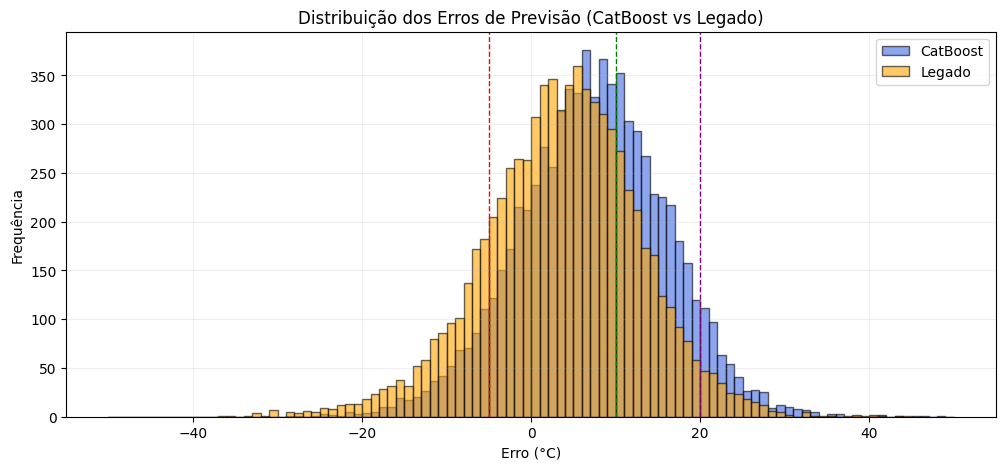

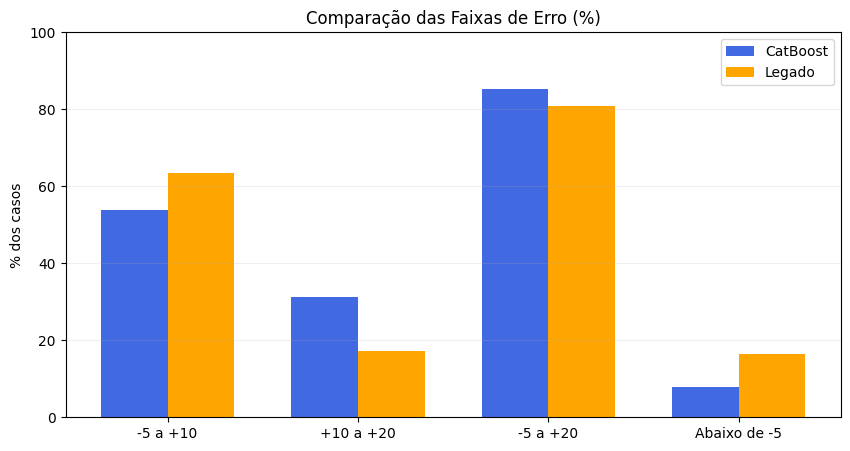

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Garantir que as variáveis de percentuais e contagens existem
if 'dentro_faixa_10_20' not in locals():
    faixa_min_10_20 = 10
    faixa_max_10_20 = 20
    dentro_faixa_10_20 = ((calcular_5_10 > faixa_min_10_20) & (calcular_5_10 <= faixa_max_10_20)).sum()
if 'pct_dentro_10_20' not in locals():
    pct_dentro_10_20 = 100 * dentro_faixa_10_20 / total if 'total' in locals() and total > 0 else 0
if 'dentro_faixa_10_20_legado' not in locals():
    faixa_min_10_20 = 10
    faixa_max_10_20 = 20
    dentro_faixa_10_20_legado = ((calcular_5_10_legado > faixa_min_10_20) & (calcular_5_10_legado <= faixa_max_10_20)).sum()
if 'pct_dentro_10_20_legado' not in locals():
    pct_dentro_10_20_legado = 100 * dentro_faixa_10_20_legado / total_legado if 'total_legado' in locals() and total_legado > 0 else 0

# Histograma dos erros lado a lado
plt.figure(figsize=(12,5))
plt.hist(calcular_5_10, bins=np.arange(-50,51,1), alpha=0.6, label='CatBoost', color='royalblue', edgecolor='black')
plt.hist(calcular_5_10_legado, bins=np.arange(-50,51,1), alpha=0.6, label='Legado', color='orange', edgecolor='black')
plt.axvline(-5, color='red', linestyle='--', lw=1)
plt.axvline(10, color='green', linestyle='--', lw=1)
plt.axvline(20, color='purple', linestyle='--', lw=1)
plt.title('Distribuição dos Erros de Previsão (CatBoost vs Legado)')
plt.xlabel('Erro (°C)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


faixas_labels = ['-5 a +10','+10 a +20','-5 a +20','Abaixo de -5']
catboost_vals = [pct_dentro, pct_dentro_10_20, pct_dentro_m5_20, pct_abaixo_m5]
legado_vals = [pct_dentro_legado, pct_dentro_10_20_legado, pct_dentro_m5_20_legado, pct_abaixo_m5_legado]

x = np.arange(len(faixas_labels))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, catboost_vals, width, label='CatBoost', color='royalblue')
plt.bar(x + width/2, legado_vals, width, label='Legado', color='orange')
plt.ylabel('% dos casos')
plt.title('Comparação das Faixas de Erro (%)')
plt.xticks(x, faixas_labels)
plt.ylim(0,100)
plt.legend()
plt.grid(axis='y', alpha=0.2)
plt.show()

In [77]:


print("="*55)
print(f"{'COMPARAÇÃO DE FAIXAS DE ERRO':^55}")
print("="*55)
print(f"{'Faixa':<22} | {'CatBoost':>13} | {'Legado':>13}")
print("-"*55)
print(f"{'Total de valores':<22} | {total:>13,} | {total_legado:>13,}")
print(f"{'Dentro [-5, +10]':<22} | {dentro_faixa:>6} ({pct_dentro:5.2f}%) | {dentro_faixa_legado:>6} ({pct_dentro_legado:5.2f}%)")
print(f"{'Fora da faixa':<22} | {fora_faixa:>6} ({pct_fora:5.2f}%) | {fora_faixa_legado:>6} ({pct_fora_legado:5.2f}%)")
print(f"{'Entre +10 e +20':<22} | {dentro_faixa_10_20:>6} ({pct_dentro_10_20:5.2f}%) | {dentro_faixa_10_20_legado:>6} ({pct_dentro_10_20_legado:5.2f}%)")
print(f"{'Entre -5 e +20':<22} | {dentro_faixa_m5_20:>6} ({pct_dentro_m5_20:5.2f}%) | {dentro_faixa_m5_20_legado:>6} ({pct_dentro_m5_20_legado:5.2f}%)")
print(f"{'Abaixo de -5':<22} | {abaixo_m5:>6} ({pct_abaixo_m5:5.2f}%) | {abaixo_m5_legado:>6} ({pct_abaixo_m5_legado:5.2f}%)")
print("="*55)

             COMPARAÇÃO DE FAIXAS DE ERRO              
Faixa                  |      CatBoost |        Legado
-------------------------------------------------------
Total de valores       |         7,485 |         7,485
Dentro [-5, +10]       |   4035 (53.91%) |   4755 (63.53%)
Fora da faixa          |   3450 (46.09%) |   2730 (36.47%)
Entre +10 e +20        |   2343 (31.30%) |   1295 (17.30%)
Entre -5 e +20         |   6378 (85.21%) |   6050 (80.83%)
Abaixo de -5           |    594 ( 7.94%) |   1229 (16.42%)
